# 06 — Multi-Site Radar Terrain Visibility Comparison
## เปรียบเทียบสถานีปัจจุบันกับตำแหน่งเสนอใหม่ภายใต้เงื่อนไขเดียวกัน

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก Notebook 00–05

ใน Notebook 05 เราเปลี่ยน **elevation angle** แต่คง radar site เดิมไว้

Notebook 06 จะเปลี่ยนคำถามเป็น

> **ถ้าใช้ radar geometry และวิธีวิเคราะห์เดียวกัน ตำแหน่งใดให้ terrain visibility ดีกว่า?**

เราจะเปรียบเทียบ 4 ตำแหน่งจาก metadata:

- สถานีปัจจุบันที่ **Tha Wang Pha**
- candidate ที่ **Phu Phiang**
- candidate ที่ **Woranakhon, Pua**
- candidate บนพื้นที่สูงที่ **Phu Kha, Pua**

เพื่อหลีกเลี่ยงความสับสนของรหัส A/B/C Notebook นี้จะใช้ **ชื่อสถานที่จริงเป็น scientific identity หลัก** และเก็บ `site_id` เดิมไว้เพียงเพื่อเชื่อมกับ metadata

การเปรียบเทียบทั้งหมดเป็น controlled comparison โดยใช้

$$
\theta
=
0.5^\circ,\;
1.0^\circ,\;
1.5^\circ,\;
2.0^\circ
$$

และใช้ DEM, beamwidth, $k$-factor, range geometry, thresholds และ algorithm เดียวกัน

### รูปแบบสมการสำหรับ Google Colab

Notebook นี้ใช้ `$ ... $` สำหรับสมการในบรรทัด และ `$$ ... $$` สำหรับสมการแยกบรรทัด

## 1. Working Hypothesis

จากบริบทการเลือกตำแหน่ง radar เราตั้งสมมติฐานเพื่อทดสอบว่า

$$
H_1:
\mathrm{Phu\ Phiang}
\text{ มี low-elevation terrain visibility ดีกว่า }
\mathrm{Tha\ Wang\ Pha}
$$

โดยเฉพาะภายในช่วงที่สำคัญต่อการตรวจฝนระดับต่ำ

$$
0-100\ \mathrm{km}
$$

Notebook จะ **ไม่กำหนดคำตอบไว้ล่วงหน้า** แต่ใช้ PBB/CBB และ spatial metrics เป็นหลักฐานทดสอบสมมติฐาน

## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- ออกแบบ controlled comparison ระหว่าง radar sites
- แยก **site effect** ออกจาก **elevation effect**
- คำนวณ PBB/CBB สำหรับหลาย sites × หลาย elevations
- เปรียบเทียบ CBB maps ด้วย scale เดียวกัน
- ใช้ area-weighted clear/partial/severe coverage
- ประเมิน clear azimuth fraction ที่ระยะเป้าหมาย
- ใช้ D10/D50 อย่างระมัดระวังเมื่อข้อมูลเป็น right-censored ที่ 240 km
- เปรียบเทียบ MUE distribution ระหว่าง sites
- คำนวณ improvement ของ Phu Phiang เทียบกับสถานีปัจจุบัน
- อธิบายว่าทำไมไม่ควร subtract CBB arrays ของต่าง site โดยตรงตาม polar index
- เตรียม metrics สำหรับ decision-support notebook ถัดไป

# Part A — หลักการของ Multi-Site Comparison

## 3. เปลี่ยน Site แต่คง Physics เดิม

เพื่อให้ผลต่างที่เห็นตีความเป็น **site effect** ได้ เราคงตัวแปรต่อไปนี้ไว้เหมือนกันทุกตำแหน่ง:

$$
\beta = 1.0^\circ
$$

$$
k=\frac{4}{3}
$$

$$
r_{\max}=240\ \mathrm{km}
$$

รวมทั้ง DEM, range spacing, azimuth spacing, PBB/CBB algorithm และ threshold definitions

สิ่งที่เปลี่ยนคือ

$$
(\lambda,\phi,H_{\mathrm{radar}})
$$

หรือ longitude, latitude และ radar altitude ของแต่ละ site

## 4. Antenna Height Assumption

เพื่อให้เป็น controlled comparison Notebook นี้ยังใช้

$$
H_{\mathrm{antenna,AGL}}=30\ \mathrm{m}
$$

เหมือนกันทุก site

ดังนั้น

$$
H_{\mathrm{radar,MSL}}
=
H_{\mathrm{nativeDEM}}
+
30
$$

นี่เป็น **teaching/research-screening assumption** ไม่ใช่ final engineering design

สำหรับการเลือก site จริง ต้องแทนด้วย surveyed ground elevation และ actual antenna feed height ของแต่ละสถานี

## 5. Metrics หลัก

สำหรับแต่ละ site และ elevation จะคำนวณอย่างน้อย 4 กลุ่ม

### 5.1 Area-weighted coverage

$$
A_{\mathrm{clear}}
,\quad
A_{\mathrm{partial}}
,\quad
A_{\mathrm{severe}}
$$

โดย

$$
CBB<0.10
$$

ถือเป็น clear/weakly affected

### 5.2 Clear azimuth fraction ณ ระยะเป้าหมาย

เช่นที่ 100 km:

$$
F_{\mathrm{clear},100}
=
\frac{
N(CBB_{100}<0.10)
}{
N_{\mathrm{azimuth}}
}
$$

### 5.3 D10 และ D50

$$
D_{10}
=
\min(r:CBB\ge0.10)
$$

$$
D_{50}
=
\min(r:CBB\ge0.50)
$$

### 5.4 Minimum Usable Elevation

$$
MUE
=
\min
\left[
\theta:
CBB(\theta)<0.10
\right]
$$

## 6. D10/D50 เป็นข้อมูลแบบ Censored ได้

หาก ray หนึ่งไม่ถึง CBB = 0.10 ภายใน 240 km เราไม่ทราบว่า threshold จะเกิดที่ 260, 300 km หรือไม่เกิดเลย

ดังนั้นควรตีความเป็น

$$
D_{10}>240\ \mathrm{km}
$$

ไม่ใช่ missing data

Notebook นี้จึงรายงานทั้ง

- percentage ของ azimuths ที่ **threshold not reached**
- median D10/D50 เฉพาะ rays ที่ถึง threshold

เพื่อไม่ให้การใช้ `NaN` ทำให้ site ที่ดีถูกตีความผิด

## 7. ห้ามลบ CBB ของต่าง Site ตาม Polar Index โดยตรง

แม้ arrays ของทุก site มี shape เดียวกัน

$$
360\times480
$$

แต่ polar gate

$$
(\alpha_i,r_j)
$$

ของ Tha Wang Pha และ Phu Phiang อยู่คนละตำแหน่งบนพื้นโลก

ดังนั้น

$$
CBB_{\mathrm{PhuPhiang}}(\alpha_i,r_j)
-
CBB_{\mathrm{Current}}(\alpha_i,r_j)
$$

ไม่ใช่ spatial difference ของพื้นที่เดียวกัน

Notebook นี้จึงเปรียบเทียบ sites ด้วย **summary metrics ที่มี physical meaning**

หากต้องการ spatial difference ที่ตำแหน่งพื้นดินเดียวกัน ต้อง regrid ทุก site ลงบน **common Cartesian grid** ก่อน ซึ่งจะเป็นหัวข้อของ decision-support workflow ภายหลัง

In [4]:
# ============================================================
# STEP 1 — Install required packages
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "wradlib": "wradlib==2.9.5",
    "rasterio": "rasterio",
    "pyproj": "pyproj",
}

to_install = [
    pip_name
    for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if to_install:
    print("Installing:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"]
        + to_install
    )

print("✓ Package check complete")

✓ Package check complete


In [5]:
# ============================================================
# STEP 2 — Imports and software environment
# ============================================================

from pathlib import Path
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.transform import rowcol
from matplotlib.patches import Circle
from matplotlib.colors import LightSource

from pyproj import CRS
import wradlib as wrl

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("wradlib     :", wrl.__version__)
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", mpl.__version__)
print("Rasterio    :", rasterio.__version__)

if wrl.__version__ != "2.9.5":
    print(
        "\n⚠ Notebook 06 was developed against wradlib 2.9.5. "
        "Review API compatibility if another version is used."
    )

Software environment
--------------------
Python      : 3.13.15
wradlib     : 2.9.5
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [6]:
# ============================================================
# STEP 3 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
# ============================================================
# STEP 4 — Paths and visualization standards
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

SITE_CSV = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)

GEOMETRY_JSON = (
    METADATA_DIR /
    "02_radar_beam_geometry_parameters.json"
)

DEM_CMAP = "terrain"

BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM:", DEM_PATH)
print("Site metadata:", SITE_CSV)

DEM: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
Site metadata: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_site_elevation_native_vs_1km_MAX.csv


# Part B — Site Identity และ Metadata QC

## 8. ใช้ Place-based Labels

เราจะสร้างชื่อเชิงความหมายดังนี้

- `CURRENT_THA_WANG_PHA`
- `PHU_PHIANG`
- `WORANAKHON_PUA`
- `PHU_KHA_HIGH`

โดยอาศัย `site_name` และ `status` ใน metadata

วิธีนี้ลดความสับสนจากรหัส `CAND_A`, `CAND_B`, `CAND_C`

In [8]:
# ============================================================
# STEP 5 — Dependency check and resolve site identities
# ============================================================

checks = {
    "1-km DEM exists": DEM_PATH.exists(),
    "Radar-site metadata exists": SITE_CSV.exists(),
    "Beam-geometry metadata exists": GEOMETRY_JSON.exists(),
}

for label, ok in checks.items():
    print(("✓" if ok else "✗"), label)

if not all(checks.values()):
    raise RuntimeError(
        "Required outputs from Notebook 01–02 are missing."
    )

sites = pd.read_csv(SITE_CSV)

with open(
    GEOMETRY_JSON,
    "r",
    encoding="utf-8",
) as f:
    geometry = json.load(f)


def infer_site_role(row):
    name = str(row["site_name"]).lower()
    status = str(row["status"]).lower()

    if (
        "tha wang pha" in name
        or status == "existing"
    ):
        return "CURRENT_THA_WANG_PHA"

    if "phu phiang" in name:
        return "PHU_PHIANG"

    if "woranakhon" in name:
        return "WORANAKHON_PUA"

    if "phu kha" in name:
        return "PHU_KHA_HIGH"

    return "OTHER_" + re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        str(row["site_id"]),
    ).strip("_")


def display_name_from_role(role):
    mapping = {
        "CURRENT_THA_WANG_PHA": "Current: Tha Wang Pha",
        "PHU_PHIANG": "Phu Phiang",
        "WORANAKHON_PUA": "Woranakhon, Pua",
        "PHU_KHA_HIGH": "Phu Kha high site",
    }
    return mapping.get(role, role)


sites["site_role"] = sites.apply(
    infer_site_role,
    axis=1,
)

sites["display_name"] = sites[
    "site_role"
].map(
    display_name_from_role
)

required_roles = [
    "CURRENT_THA_WANG_PHA",
    "PHU_PHIANG",
    "WORANAKHON_PUA",
    "PHU_KHA_HIGH",
]

role_counts = (
    sites["site_role"]
    .value_counts()
    .to_dict()
)

for role in required_roles:
    if role_counts.get(role, 0) != 1:
        raise ValueError(
            f"Expected exactly one {role}, "
            f"found {role_counts.get(role, 0)}."
        )

role_order = {
    role: i
    for i, role in enumerate(required_roles)
}

sites["role_order"] = (
    sites["site_role"]
    .map(role_order)
)

sites = (
    sites
    .sort_values("role_order")
    .reset_index(drop=True)
)

display(
    sites[
        [
            "site_role",
            "site_id",
            "site_name",
            "native_dem_m",
        ]
    ].style.format({
        "native_dem_m": "{:.1f}",
    })
)

print("\n✓ All four site identities resolved")

✓ 1-km DEM exists
✓ Radar-site metadata exists
✓ Beam-geometry metadata exists


,site_role,site_id,site_name,native_dem_m
0,CURRENT_THA_WANG_PHA,CURRENT,"Tha Wang Pha, Nan",233.0
1,PHU_PHIANG,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0
2,WORANAKHON_PUA,CAND_B,"Woranakhon, Pua, Nan",347.0
3,PHU_KHA_HIGH,CAND_C,"Phu Kha, Pua, Nan",1296.0



✓ All four site identities resolved


## 9. Controlled Comparison Configuration

เราจะใช้ elevations

$$
0.5^\circ,\quad
1.0^\circ,\quad
1.5^\circ,\quad
2.0^\circ
$$

สำหรับทุก site

เกณฑ์เดิม:

$$
CBB<0.10
$$

clear/weakly affected

$$
0.10\le CBB<0.50
$$

partial blockage

$$
CBB\ge0.50
$$

severe blockage

In [9]:
# ============================================================
# STEP 6 — Analysis configuration
# ============================================================

ELEVATIONS_DEG = np.array(
    [0.5, 1.0, 1.5, 2.0],
    dtype=float,
)

CLEAR_THRESHOLD = 0.10
SEVERE_THRESHOLD = 0.50

EARTH_RADIUS_M = float(
    geometry["earth_radius_m"]
)

K_STANDARD = float(
    geometry["k_standard"]
)

NRAYS = 360

NBINS = int(
    geometry["number_of_range_bins"]
)

RANGE_RES_M = float(
    geometry["range_resolution_m"]
)

MAX_RANGE_M = float(
    geometry["maximum_nominal_range_km"]
) * 1000.0

BEAMWIDTH_DEG = float(
    geometry["beamwidth_deg"]
)

ANTENNA_AGL_M = float(
    geometry["antenna_agl_teaching_assumption_m"]
)

AZIMUTHS_DEG = np.arange(
    NRAYS,
    dtype=float,
)

RANGE_CENTERS_M = (
    np.arange(NBINS, dtype=float)
    + 0.5
) * RANGE_RES_M

RANGE_CENTERS_KM = (
    RANGE_CENTERS_M / 1000.0
)

RANGE_EDGES_M = (
    np.arange(NBINS + 1, dtype=float)
    * RANGE_RES_M
)

TARGET_RANGES_KM = [
    50,
    100,
    150,
    200,
    240,
]

RANGE_BANDS = [
    (0, 50),
    (50, 100),
    (100, 150),
    (150, 200),
    (200, 240),
]

print("Sites       :", len(sites))
print("Elevations  :", ELEVATIONS_DEG)
print("Polar grid  :", f"{NRAYS} × {NBINS}")
print("Max range   :", f"{MAX_RANGE_M/1000:.0f} km")
print("Beamwidth   :", f"{BEAMWIDTH_DEG:.1f}°")
print("k-factor    :", f"{K_STANDARD:.6f}")

Sites       : 4
Elevations  : [0.5 1.  1.5 2. ]
Polar grid  : 360 × 480
Max range   : 240 km
Beamwidth   : 1.0°
k-factor    : 1.333333


In [10]:
# ============================================================
# STEP 7 — Load DEM
# ============================================================

with rasterio.open(
    DEM_PATH
) as ds:
    dem = ds.read(
        1,
        masked=True,
    )

    dem_data = np.asarray(
        dem.filled(np.nan),
        dtype=np.float32,
    )

    dem_transform = ds.transform
    dem_crs = CRS.from_user_input(
        ds.crs
    )
    dem_bounds = ds.bounds
    dem_res = ds.res

print("DEM CRS       :", dem_crs)
print("DEM resolution:", dem_res)
print("DEM shape     :", dem.shape)

DEM CRS       : PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]
DEM resolution: (1000.0, 1000.0)
DEM shape     : (552, 529)


In [11]:
# ============================================================
# STEP 8 — Shared polar geometry and helper functions
# ============================================================

az2d = np.repeat(
    AZIMUTHS_DEG[:, None],
    NBINS,
    axis=1,
)

range2d = np.repeat(
    RANGE_CENTERS_M[None, :],
    NRAYS,
    axis=0,
)

beam_radius_m = np.asarray(
    wrl.util.half_power_radius(
        RANGE_CENTERS_M,
        BEAMWIDTH_DEG,
    ),
    dtype=np.float32,
)

beam_radius_2d = np.broadcast_to(
    beam_radius_m[None, :],
    (NRAYS, NBINS),
)


def sample_dem_at_xy(
    x_m,
    y_m,
):
    flat_x = np.asarray(
        x_m
    ).ravel()

    flat_y = np.asarray(
        y_m
    ).ravel()

    rows, cols = rowcol(
        dem_transform,
        flat_x,
        flat_y,
    )

    rows = np.asarray(
        rows,
        dtype=int,
    )

    cols = np.asarray(
        cols,
        dtype=int,
    )

    inside = (
        (rows >= 0)
        & (rows < dem_data.shape[0])
        & (cols >= 0)
        & (cols < dem_data.shape[1])
    )

    out = np.full(
        flat_x.shape,
        np.nan,
        dtype=np.float32,
    )

    out[inside] = dem_data[
        rows[inside],
        cols[inside],
    ]

    return out.reshape(
        np.asarray(x_m).shape
    )


def first_threshold_distance_km(
    values,
    threshold,
):
    idx = np.flatnonzero(
        np.isfinite(values)
        & (values >= threshold)
    )

    if idx.size == 0:
        return np.nan

    return float(
        RANGE_CENTERS_KM[
            idx[0]
        ]
    )


def safe_tag(text):
    return re.sub(
        r"[^A-Za-z0-9_\-]+",
        "_",
        str(text),
    ).strip("_")


print("✓ Shared helper functions ready")

✓ Shared helper functions ready


# Part C — 4 Sites × 4 Elevations

## 10. Computational Experiment

จำนวน scenarios คือ

$$
4\ \mathrm{sites}
\times
4\ \mathrm{elevations}
=
16
$$

ทุก scenario ใช้ algorithm เดียวกัน:

$$
DEM
\rightarrow
\mathrm{radar\ geometry}
\rightarrow
PBB
\rightarrow
CBB
$$

In [12]:
# ============================================================
# STEP 9 — Compute PBB/CBB for all 16 scenarios
# ============================================================

results = {}

for _, site in sites.iterrows():
    role = str(
        site["site_role"]
    )

    results[role] = {}

    radar_lon = float(
        site["longitude"]
    )

    radar_lat = float(
        site["latitude"]
    )

    radar_ground_msl_m = float(
        site["native_dem_m"]
    )

    radar_altitude_msl_m = (
        radar_ground_msl_m
        + ANTENNA_AGL_M
    )

    print()
    print("=" * 74)
    print(
        role,
        "—",
        site["site_name"],
    )
    print("=" * 74)

    for elev in ELEVATIONS_DEG:
        print(
            f"Processing {elev:.1f}° ..."
        )

        el2d = np.full(
            (NRAYS, NBINS),
            elev,
            dtype=float,
        )

        coords = (
            wrl.georef.polar
            .spherical_to_proj(
                range2d,
                az2d,
                el2d,
                (
                    radar_lon,
                    radar_lat,
                    radar_altitude_msl_m,
                ),
                crs=dem_crs,
                ke=K_STANDARD,
            )
        )

        coords = np.asarray(
            coords,
            dtype=np.float64,
        )

        x_m = coords[..., 0].astype(
            np.float32
        )

        y_m = coords[..., 1].astype(
            np.float32
        )

        beam_center_msl_m = (
            coords[..., 2]
            .astype(np.float32)
        )

        terrain_msl_m = sample_dem_at_xy(
            x_m,
            y_m,
        )

        missing = ~np.isfinite(
            terrain_msl_m
        )

        terrain_calc = (
            terrain_msl_m.copy()
        )

        terrain_calc[
            missing
        ] = -500.0

        with np.errstate(
            invalid="ignore",
            divide="ignore",
        ):
            pbb = (
                wrl.qual
                .beam_block_frac(
                    terrain_calc,
                    beam_center_msl_m,
                    beam_radius_2d,
                )
            )

        pbb = np.asarray(
            pbb,
            dtype=np.float32,
        )

        pbb = np.clip(
            pbb,
            0.0,
            1.0,
        )

        pbb[
            missing
        ] = np.nan

        pbb_for_cbb = (
            pbb.copy()
        )

        pbb_for_cbb[
            ~np.isfinite(
                pbb_for_cbb
            )
        ] = 0.0

        cbb = (
            wrl.qual
            .cum_beam_block_frac(
                pbb_for_cbb
            )
        )

        cbb = np.asarray(
            cbb,
            dtype=np.float32,
        )

        cbb[
            missing
        ] = np.nan

        results[role][float(elev)] = {
            "x_m": x_m,
            "y_m": y_m,
            "beam_center_msl_m": beam_center_msl_m,
            "terrain_msl_m": terrain_msl_m,
            "pbb": pbb,
            "cbb": cbb,
            "missing": missing,
            "radar_altitude_msl_m": radar_altitude_msl_m,
        }

        print(
            "  valid terrain:",
            f"{100*(1-missing.mean()):.3f}%"
        )

print("\n✓ All 16 site/elevation scenarios calculated")


CURRENT_THA_WANG_PHA — Tha Wang Pha, Nan
Processing 0.5° ...
  valid terrain: 100.000%
Processing 1.0° ...
  valid terrain: 100.000%
Processing 1.5° ...
  valid terrain: 100.000%
Processing 2.0° ...
  valid terrain: 100.000%

PHU_PHIANG — Tha Nao, Phu Phiang, Nan
Processing 0.5° ...
  valid terrain: 100.000%
Processing 1.0° ...
  valid terrain: 100.000%
Processing 1.5° ...
  valid terrain: 100.000%
Processing 2.0° ...
  valid terrain: 100.000%

WORANAKHON_PUA — Woranakhon, Pua, Nan
Processing 0.5° ...
  valid terrain: 100.000%
Processing 1.0° ...
  valid terrain: 100.000%
Processing 1.5° ...
  valid terrain: 100.000%
Processing 2.0° ...
  valid terrain: 100.000%

PHU_KHA_HIGH — Phu Kha, Pua, Nan
Processing 0.5° ...
  valid terrain: 100.000%
Processing 1.0° ...
  valid terrain: 100.000%
Processing 1.5° ...
  valid terrain: 100.000%
Processing 2.0° ...
  valid terrain: 100.000%

✓ All 16 site/elevation scenarios calculated


In [13]:
# ============================================================
# STEP 10 — Numerical QC across all scenarios
# ============================================================

qc_rows = []

for _, site in sites.iterrows():
    role = site["site_role"]

    for elev in ELEVATIONS_DEG:
        item = results[
            role
        ][
            float(elev)
        ]

        pbb = item["pbb"]
        cbb = item["cbb"]
        missing = item["missing"]

        complete_rays = (
            ~missing.any(
                axis=1
            )
        )

        monotonic = False

        if complete_rays.any():
            monotonic = bool(
                np.all(
                    np.diff(
                        cbb[
                            complete_rays,
                            :
                        ],
                        axis=1,
                    )
                    >= -1e-7
                )
            )

        qc_rows.append({
            "site_role": role,
            "site_id": site["site_id"],
            "elevation_deg": elev,
            "valid_terrain_pct": (
                100.0
                * (1.0 - missing.mean())
            ),
            "pbb_min": float(
                np.nanmin(pbb)
            ),
            "pbb_max": float(
                np.nanmax(pbb)
            ),
            "cbb_min": float(
                np.nanmin(cbb)
            ),
            "cbb_max": float(
                np.nanmax(cbb)
            ),
            "cbb_monotonic_complete_rays": monotonic,
        })

qc_table = pd.DataFrame(
    qc_rows
)

display(
    qc_table.style.format({
        "elevation_deg": "{:.1f}",
        "valid_terrain_pct": "{:.3f}",
        "pbb_min": "{:.3f}",
        "pbb_max": "{:.3f}",
        "cbb_min": "{:.3f}",
        "cbb_max": "{:.3f}",
    })
)

,site_role,site_id,elevation_deg,valid_terrain_pct,pbb_min,pbb_max,cbb_min,cbb_max,cbb_monotonic_complete_rays
0,CURRENT_THA_WANG_PHA,CURRENT,0.5,100.000,0.000,1.000,0.000,1.000,True
1,CURRENT_THA_WANG_PHA,CURRENT,1.0,100.000,0.000,1.000,0.000,1.000,True
2,CURRENT_THA_WANG_PHA,CURRENT,1.5,100.000,0.000,1.000,0.000,1.000,True
3,CURRENT_THA_WANG_PHA,CURRENT,2.0,100.000,0.000,1.000,0.000,1.000,True
4,PHU_PHIANG,CAND_A,0.5,100.000,0.000,1.000,0.000,1.000,True
5,PHU_PHIANG,CAND_A,1.0,100.000,0.000,1.000,0.000,1.000,True
6,PHU_PHIANG,CAND_A,1.5,100.000,0.000,1.000,0.000,1.000,True
7,PHU_PHIANG,CAND_A,2.0,100.000,0.000,0.991,0.000,0.991,True
8,WORANAKHON_PUA,CAND_B,0.5,100.000,0.000,1.000,0.000,1.000,True
9,WORANAKHON_PUA,CAND_B,1.0,100.000,0.000,1.000,0.000,1.000,True


# Part D — Figure 1: Local Site Context

แผนที่นี้ใช้ชื่อสถานที่จริงแทน candidate code

- Current = ดาวสีส้ม
- Candidates = สามเหลี่ยมสีขาวขอบดำ
- Phu Phiang = candidate ที่ highlight ด้วยขอบหนากว่า
- DEM = `terrain`

การวาง label ใช้ manual offsets เพื่อป้องกันข้อความซ้อนกัน

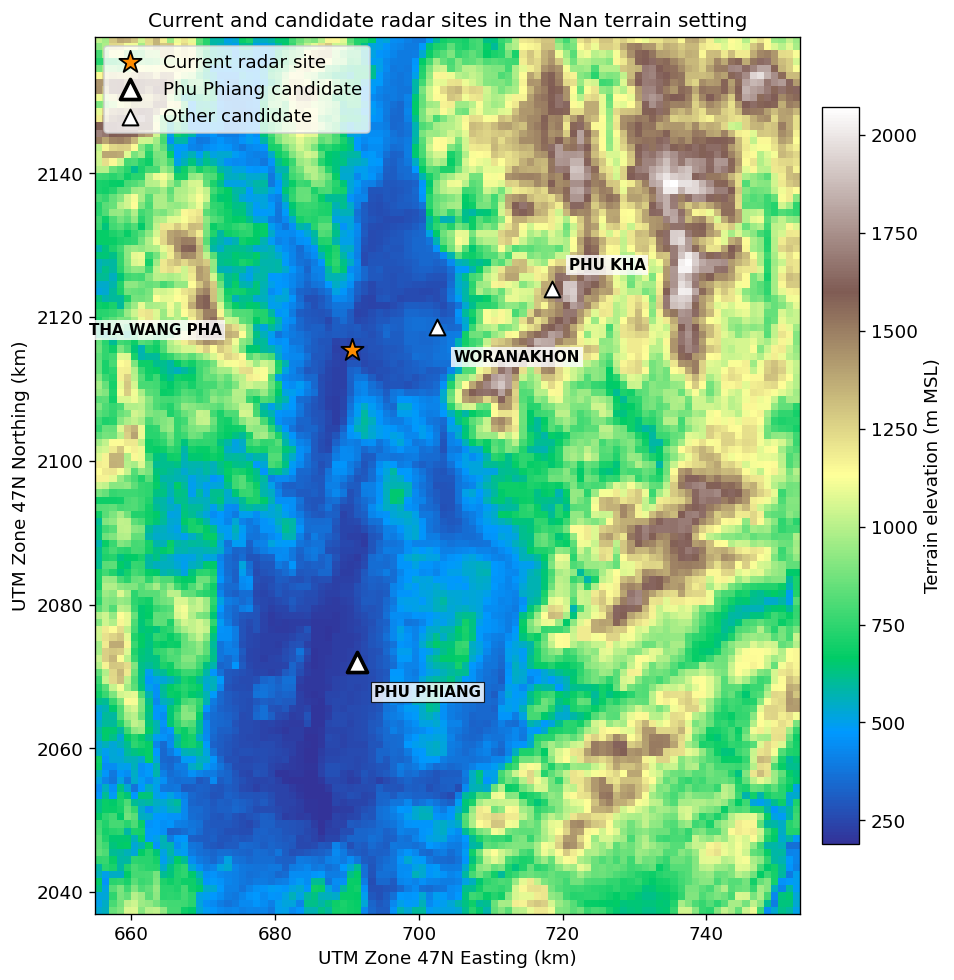

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_01_Nan_Radar_Site_Comparison_Terrain.png


In [14]:
# ============================================================
# STEP 11 — Figure 1: terrain and four comparison sites
# ============================================================

local_buffer_m = 35_000.0

local_xmin = (
    sites["utm_x_m"].min()
    - local_buffer_m
)

local_xmax = (
    sites["utm_x_m"].max()
    + local_buffer_m
)

local_ymin = (
    sites["utm_y_m"].min()
    - local_buffer_m
)

local_ymax = (
    sites["utm_y_m"].max()
    + local_buffer_m
)

with rasterio.open(
    DEM_PATH
) as ds:
    local_window = (
        rasterio.windows
        .from_bounds(
            local_xmin,
            local_ymin,
            local_xmax,
            local_ymax,
            transform=ds.transform,
        )
        .round_offsets()
        .round_lengths()
    )

    local_dem = ds.read(
        1,
        window=local_window,
        masked=True,
    )

    local_bounds = (
        rasterio.windows
        .bounds(
            local_window,
            ds.transform,
        )
    )

local_extent_km = [
    local_bounds[0] / 1000.0,
    local_bounds[2] / 1000.0,
    local_bounds[1] / 1000.0,
    local_bounds[3] / 1000.0,
]

label_offsets = {
    "CURRENT_THA_WANG_PHA": (-78, 12),
    "PHU_PHIANG": (10, -18),
    "WORANAKHON_PUA": (10, -18),
    "PHU_KHA_HIGH": (10, 14),
}

short_labels = {
    "CURRENT_THA_WANG_PHA": "THA WANG PHA",
    "PHU_PHIANG": "PHU PHIANG",
    "WORANAKHON_PUA": "WORANAKHON",
    "PHU_KHA_HIGH": "PHU KHA",
}

fig, ax = plt.subplots(
    figsize=(9.6, 8.3)
)

im = ax.imshow(
    local_dem,
    cmap=DEM_CMAP,
    extent=local_extent_km,
    origin="upper",
)

for _, row in sites.iterrows():
    role = row["site_role"]

    x_km = (
        float(row["utm_x_m"])
        / 1000.0
    )

    y_km = (
        float(row["utm_y_m"])
        / 1000.0
    )

    is_current = (
        role
        == "CURRENT_THA_WANG_PHA"
    )

    is_phuphiang = (
        role
        == "PHU_PHIANG"
    )

    if is_current:
        ax.scatter(
            x_km,
            y_km,
            marker=CURRENT_MARKER,
            s=195,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=8,
            label="Current radar site",
        )
    else:
        ax.scatter(
            x_km,
            y_km,
            marker=CANDIDATE_MARKER,
            s=145 if is_phuphiang else 90,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=2.2 if is_phuphiang else 1.2,
            zorder=8,
            label=(
                "Phu Phiang candidate"
                if is_phuphiang
                else "Other candidate"
            ),
        )

    dx, dy = label_offsets[
        role
    ]

    ax.annotate(
        short_labels[
            role
        ],
        xy=(
            x_km,
            y_km,
        ),
        xytext=(
            dx,
            dy,
        ),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha=(
            "left"
            if dx >= 0
            else "right"
        ),
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": (
                "black"
                if is_phuphiang
                else "none"
            ),
            "linewidth": 0.7,
            "alpha": 0.82,
            "pad": 1.5,
        },
        zorder=9,
    )

handles, labels = (
    ax.get_legend_handles_labels()
)

unique = {}

for handle, label in zip(
    handles,
    labels,
):
    if label not in unique:
        unique[label] = handle

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper left",
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)

cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)

ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)

ax.set_title(
    "Current and candidate radar sites in the Nan terrain setting"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig06_01_Nan_Radar_Site_Comparison_Terrain.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig1_path)

# Part E — Low-Elevation CBB Maps

## 11. Figures 2–5 — CBB ที่ 0.5° ของทั้ง 4 Sites

เราจะเปรียบเทียบ low-elevation visibility ก่อน เพราะ $0.5^\circ$ มีความไวต่อ terrain obstruction สูงที่สุดในชุดที่ทดสอบ

ทุกแผนที่ใช้

```python
cmap="PuRd"
vmin=0
vmax=1
```

ดังนั้นสีสามารถเปรียบเทียบกันโดยตรง

/tmp/ipykernel_1154/171490630.py:68: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


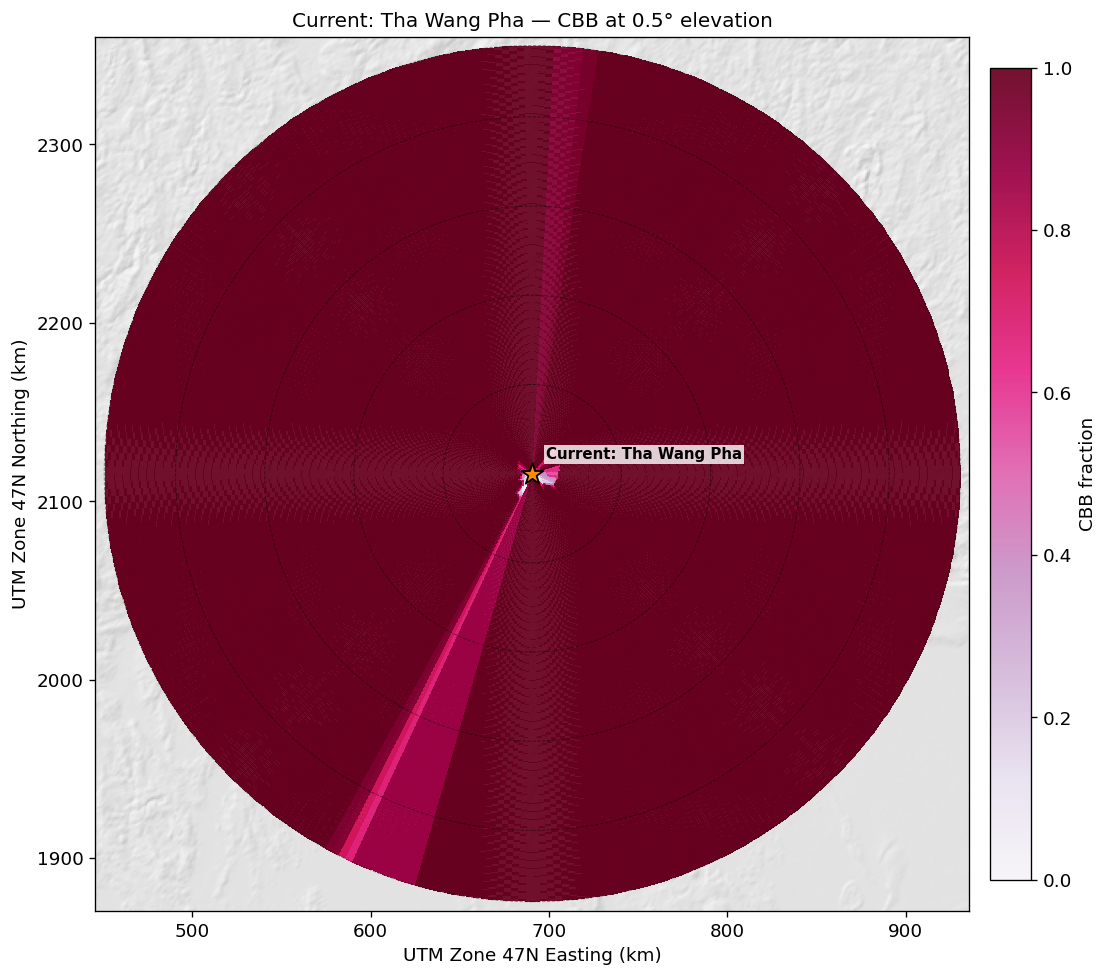

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_02_CURRENT_THA_WANG_PHA_CBB_0p5deg.png


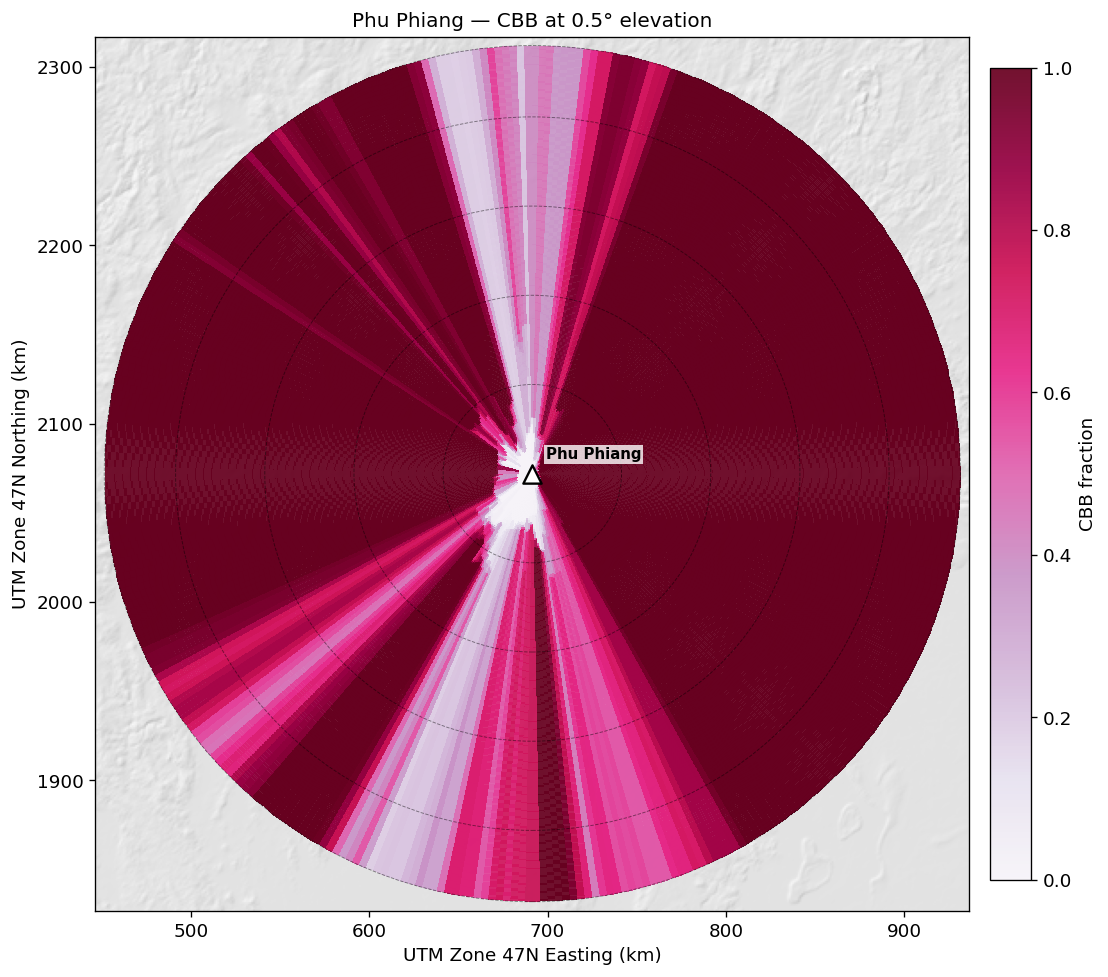

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_03_PHU_PHIANG_CBB_0p5deg.png


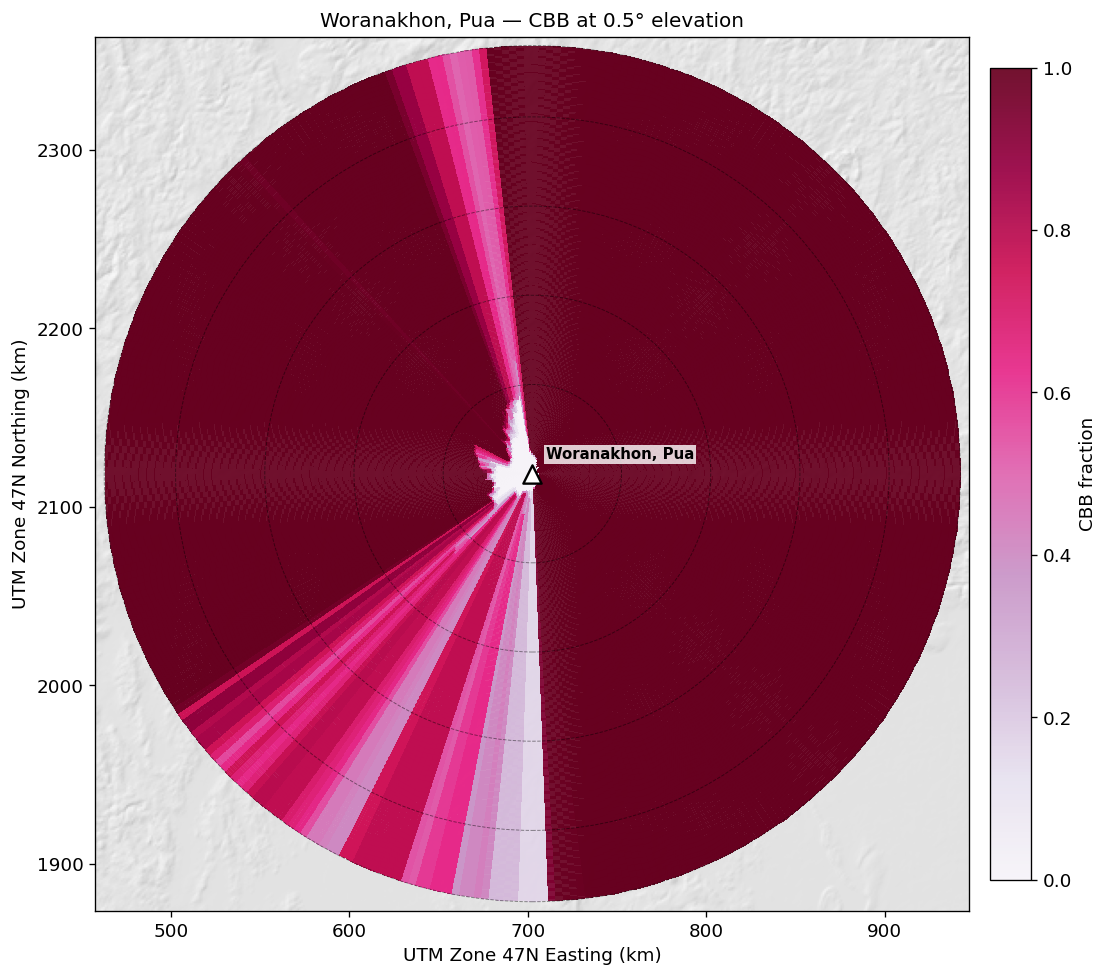

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_04_WORANAKHON_PUA_CBB_0p5deg.png


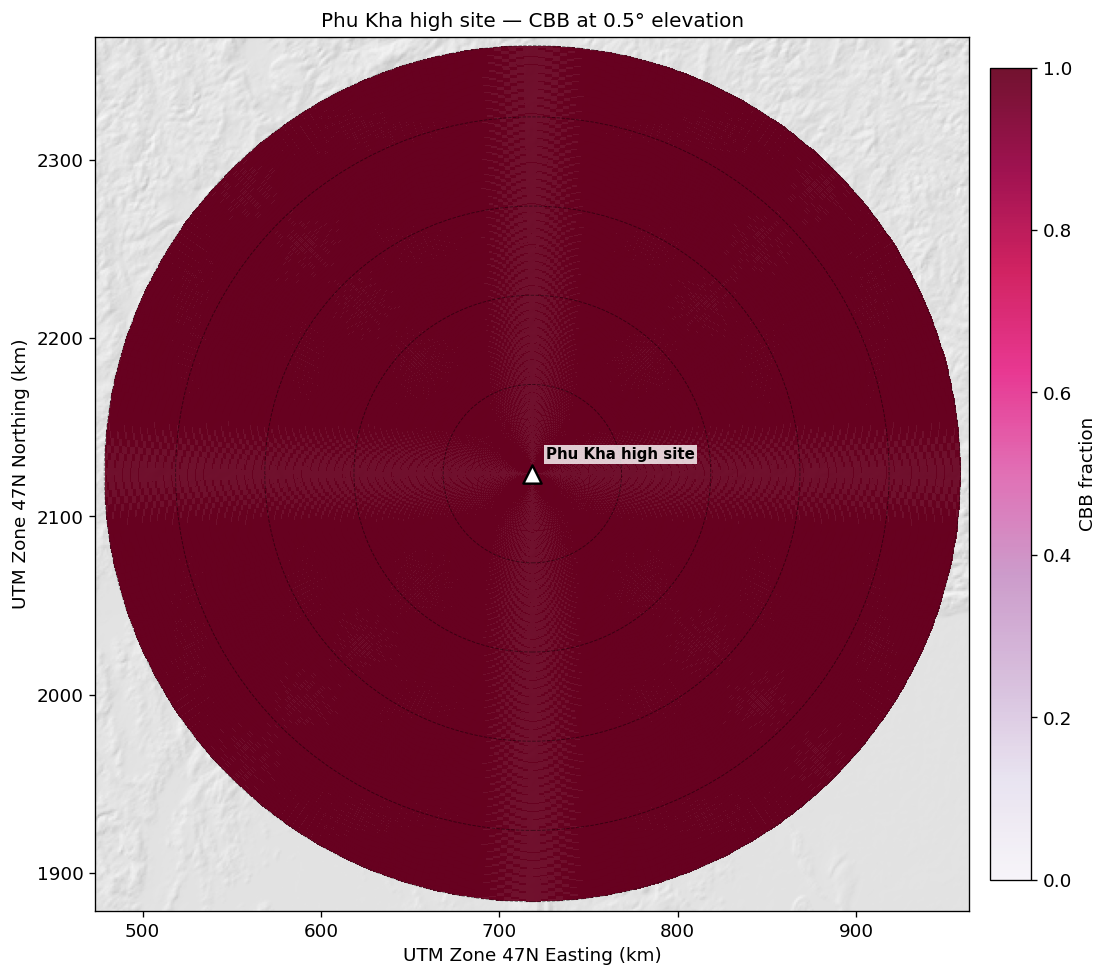

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_05_PHU_KHA_HIGH_CBB_0p5deg.png


In [15]:
# ============================================================
# STEP 12 — Figures 2–5: 0.5° CBB maps for all sites
# ============================================================

dem_for_hillshade = np.where(
    np.isfinite(dem_data),
    dem_data,
    np.nanmedian(dem_data),
)

ls = LightSource(
    azdeg=315,
    altdeg=45,
)

hillshade = ls.hillshade(
    dem_for_hillshade,
    vert_exag=1.0,
    dx=abs(dem_transform.a),
    dy=abs(dem_transform.e),
)

dem_extent_km = [
    dem_bounds.left / 1000.0,
    dem_bounds.right / 1000.0,
    dem_bounds.bottom / 1000.0,
    dem_bounds.top / 1000.0,
]

cbb_map_paths = []

for fig_number, (_, site) in enumerate(
    sites.iterrows(),
    start=2,
):
    role = site["site_role"]
    label = site["display_name"]

    item = results[
        role
    ][
        0.5
    ]

    sx = (
        float(site["utm_x_m"])
        / 1000.0
    )

    sy = (
        float(site["utm_y_m"])
        / 1000.0
    )

    fig, ax = plt.subplots(
        figsize=(9.8, 8.8)
    )

    ax.imshow(
        hillshade,
        extent=dem_extent_km,
        origin="upper",
        cmap="gray",
        alpha=0.30,
        zorder=0,
    )

    m = ax.pcolormesh(
        item["x_m"] / 1000.0,
        item["y_m"] / 1000.0,
        item["cbb"],
        cmap=BLOCKAGE_CMAP,
        vmin=BLOCKAGE_VMIN,
        vmax=BLOCKAGE_VMAX,
        shading="auto",
        alpha=0.93,
        zorder=2,
    )

    for rr in [
        50,
        100,
        150,
        200,
        240,
    ]:
        ax.add_patch(
            Circle(
                (sx, sy),
                rr,
                fill=False,
                linestyle="--",
                linewidth=0.55,
                edgecolor="black",
                alpha=0.45,
                zorder=4,
            )
        )

    if role == "CURRENT_THA_WANG_PHA":
        ax.scatter(
            sx,
            sy,
            marker=CURRENT_MARKER,
            s=185,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=8,
        )
    else:
        ax.scatter(
            sx,
            sy,
            marker=CANDIDATE_MARKER,
            s=120,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=1.4,
            zorder=8,
        )

    ax.annotate(
        label,
        (sx, sy),
        xytext=(8, 9),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 1.3,
        },
        zorder=9,
    )

    ax.set_xlim(
        sx - 245,
        sx + 245,
    )

    ax.set_ylim(
        sy - 245,
        sy + 245,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        "UTM Zone 47N Easting (km)"
    )

    ax.set_ylabel(
        "UTM Zone 47N Northing (km)"
    )

    ax.set_title(
        f"{label} — CBB at 0.5° elevation"
    )

    cbar = fig.colorbar(
        m,
        ax=ax,
        shrink=0.82,
        pad=0.02,
    )

    cbar.set_label(
        "CBB fraction"
    )

    fig.tight_layout()

    path = (
        FIGURES_DIR /
        f"Fig06_{fig_number:02d}_"
        f"{safe_tag(role)}_CBB_0p5deg.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    cbb_map_paths.append(
        str(path)
    )

    print("Saved:", path)

# Part F — Area-Weighted Coverage Metrics

## 12. Polar Gate Area

ใช้ nominal annular-sector area

$$
A_i
=
\frac{1}{2}
\left(
r_{i+1}^2-r_i^2
\right)
\Delta\alpha
$$

เพื่อให้พื้นที่ระยะไกลได้รับน้ำหนักตามขนาดจริง ไม่ใช่ทุก gate มีน้ำหนักเท่ากัน

In [16]:
# ============================================================
# STEP 13 — Build common area weights
# ============================================================

delta_az_rad = np.deg2rad(
    1.0
)

annular_sector_area_m2 = (
    0.5
    * (
        RANGE_EDGES_M[1:]**2
        - RANGE_EDGES_M[:-1]**2
    )
    * delta_az_rad
)

area_weights_m2 = np.broadcast_to(
    annular_sector_area_m2[None, :],
    (NRAYS, NBINS),
)

print(
    "Nominal 0–240 km area:",
    f"{area_weights_m2.sum()/1e6:,.1f} km²"
)

print(
    "πr²:",
    f"{np.pi*(MAX_RANGE_M/1000.0)**2:,.1f} km²"
)

Nominal 0–240 km area: 180,955.7 km²
πr²: 180,955.7 km²


In [17]:
# ============================================================
# STEP 14 — Area-weighted summary by site, elevation and range band
# ============================================================

area_rows = []

for _, site in sites.iterrows():
    role = site["site_role"]

    for elev in ELEVATIONS_DEG:
        cbb = results[
            role
        ][
            float(elev)
        ]["cbb"]

        valid = np.isfinite(
            cbb
        )

        for r0, r1 in RANGE_BANDS:
            in_band_1d = (
                (RANGE_CENTERS_KM >= r0)
                & (RANGE_CENTERS_KM < r1)
            )

            in_band = np.broadcast_to(
                in_band_1d[None, :],
                (NRAYS, NBINS),
            )

            mask = (
                valid
                & in_band
            )

            total_area = float(
                area_weights_m2[
                    mask
                ].sum()
            )

            clear = (
                mask
                & (
                    cbb
                    < CLEAR_THRESHOLD
                )
            )

            partial = (
                mask
                & (
                    cbb
                    >= CLEAR_THRESHOLD
                )
                & (
                    cbb
                    < SEVERE_THRESHOLD
                )
            )

            severe = (
                mask
                & (
                    cbb
                    >= SEVERE_THRESHOLD
                )
            )

            area_rows.append({
                "site_role": role,
                "display_name": site["display_name"],
                "site_id": site["site_id"],
                "elevation_deg": elev,
                "range_band_km": f"{r0}-{r1}",
                "valid_area_km2": total_area / 1e6,
                "clear_area_pct": (
                    100.0
                    * area_weights_m2[
                        clear
                    ].sum()
                    / total_area
                ),
                "partial_area_pct": (
                    100.0
                    * area_weights_m2[
                        partial
                    ].sum()
                    / total_area
                ),
                "severe_area_pct": (
                    100.0
                    * area_weights_m2[
                        severe
                    ].sum()
                    / total_area
                ),
            })

area_band_table = pd.DataFrame(
    area_rows
)

area_band_csv = (
    TABLES_DIR /
    "06_MultiSite_AreaWeighted_Blockage_by_RangeBand.csv"
)

area_band_table.to_csv(
    area_band_csv,
    index=False,
)

display(
    area_band_table.head(20).style.format({
        "elevation_deg": "{:.1f}",
        "valid_area_km2": "{:,.1f}",
        "clear_area_pct": "{:.2f}",
        "partial_area_pct": "{:.2f}",
        "severe_area_pct": "{:.2f}",
    })
)

print("\nSaved:")
print(area_band_csv)

,site_role,display_name,site_id,elevation_deg,range_band_km,valid_area_km2,clear_area_pct,partial_area_pct,severe_area_pct
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,0.5,0-50,"7,854.0",0.43,0.92,98.65
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,0.5,50-100,"23,561.9",0.00,0.00,100.00
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,0.5,100-150,"39,269.9",0.00,0.00,100.00
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,0.5,150-200,"54,977.9",0.00,0.00,100.00
4,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,0.5,200-240,"55,292.0",0.00,0.00,100.00
5,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,1.0,0-50,"7,854.0",2.56,7.13,90.31
6,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,1.0,50-100,"23,561.9",0.28,5.28,94.44
7,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,1.0,100-150,"39,269.9",0.28,5.28,94.44
8,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,1.0,150-200,"54,977.9",0.28,5.28,94.44
9,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,1.0,200-240,"55,292.0",0.28,5.28,94.44



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_AreaWeighted_Blockage_by_RangeBand.csv


In [18]:
# ============================================================
# STEP 15 — Scenario-level metrics for 0–100 km and 0–240 km
# ============================================================

scenario_rows = []

mask_0_100_1d = (
    RANGE_CENTERS_KM < 100.0
)

mask_0_100 = np.broadcast_to(
    mask_0_100_1d[None, :],
    (NRAYS, NBINS),
)

for _, site in sites.iterrows():
    role = site["site_role"]

    for elev in ELEVATIONS_DEG:
        cbb = results[
            role
        ][
            float(elev)
        ]["cbb"]

        valid = np.isfinite(
            cbb
        )

        def area_stats(mask):
            total = float(
                area_weights_m2[
                    mask
                ].sum()
            )

            clear = (
                mask
                & (
                    cbb
                    < CLEAR_THRESHOLD
                )
            )

            partial = (
                mask
                & (
                    cbb
                    >= CLEAR_THRESHOLD
                )
                & (
                    cbb
                    < SEVERE_THRESHOLD
                )
            )

            severe = (
                mask
                & (
                    cbb
                    >= SEVERE_THRESHOLD
                )
            )

            return (
                100.0
                * area_weights_m2[
                    clear
                ].sum()
                / total,
                100.0
                * area_weights_m2[
                    partial
                ].sum()
                / total,
                100.0
                * area_weights_m2[
                    severe
                ].sum()
                / total,
            )

        clear100, partial100, severe100 = area_stats(
            valid
            & mask_0_100
        )

        clear240, partial240, severe240 = area_stats(
            valid
        )

        scenario_rows.append({
            "site_role": role,
            "display_name": site["display_name"],
            "site_id": site["site_id"],
            "site_name": site["site_name"],
            "ground_elevation_msl_m": float(
                site["native_dem_m"]
            ),
            "elevation_deg": elev,
            "clear_area_pct_0_100km": clear100,
            "partial_area_pct_0_100km": partial100,
            "severe_area_pct_0_100km": severe100,
            "clear_area_pct_0_240km": clear240,
            "partial_area_pct_0_240km": partial240,
            "severe_area_pct_0_240km": severe240,
            "mean_cbb_gate_based": float(
                np.nanmean(cbb)
            ),
            "median_cbb_gate_based": float(
                np.nanmedian(cbb)
            ),
        })

scenario_table = pd.DataFrame(
    scenario_rows
)

scenario_csv = (
    TABLES_DIR /
    "06_MultiSite_Scenario_Coverage_Summary.csv"
)

scenario_table.to_csv(
    scenario_csv,
    index=False,
)

display(
    scenario_table.style.format({
        "ground_elevation_msl_m": "{:.1f}",
        "elevation_deg": "{:.1f}",
        "clear_area_pct_0_100km": "{:.2f}",
        "partial_area_pct_0_100km": "{:.2f}",
        "severe_area_pct_0_100km": "{:.2f}",
        "clear_area_pct_0_240km": "{:.2f}",
        "partial_area_pct_0_240km": "{:.2f}",
        "severe_area_pct_0_240km": "{:.2f}",
        "mean_cbb_gate_based": "{:.3f}",
        "median_cbb_gate_based": "{:.3f}",
    })
)

print("\nSaved:")
print(scenario_csv)

,site_role,display_name,site_id,site_name,ground_elevation_msl_m,elevation_deg,clear_area_pct_0_100km,partial_area_pct_0_100km,severe_area_pct_0_100km,clear_area_pct_0_240km,partial_area_pct_0_240km,severe_area_pct_0_240km,mean_cbb_gate_based,median_cbb_gate_based
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,"Tha Wang Pha, Nan",233.0,0.5,0.11,0.23,99.66,0.02,0.04,99.94,0.975,1.000
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,"Tha Wang Pha, Nan",233.0,1.0,0.85,5.74,93.41,0.38,5.36,94.26,0.889,1.000
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,"Tha Wang Pha, Nan",233.0,1.5,9.91,19.01,71.08,8.38,18.68,72.94,0.693,0.985
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,CURRENT,"Tha Wang Pha, Nan",233.0,2.0,34.86,16.67,48.47,33.14,17.13,49.73,0.481,0.445
4,PHU_PHIANG,Phu Phiang,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0,0.5,2.69,12.47,84.84,0.47,11.12,88.42,0.813,1.000
5,PHU_PHIANG,Phu Phiang,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0,1.0,23.50,17.84,58.66,20.15,18.25,61.60,0.579,0.682
6,PHU_PHIANG,Phu Phiang,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0,1.5,49.19,14.13,36.68,47.33,14.85,37.82,0.366,0.090
7,PHU_PHIANG,Phu Phiang,CAND_A,"Tha Nao, Phu Phiang, Nan",235.0,2.0,65.94,22.47,11.58,64.93,23.41,11.65,0.152,0.000
8,WORANAKHON_PUA,"Woranakhon, Pua",CAND_B,"Woranakhon, Pua, Nan",347.0,0.5,1.92,6.47,91.61,0.33,5.48,94.18,0.874,1.000
9,WORANAKHON_PUA,"Woranakhon, Pua",CAND_B,"Woranakhon, Pua, Nan",347.0,1.0,14.10,10.78,75.12,11.86,11.05,77.09,0.725,1.000



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_Scenario_Coverage_Summary.csv


# Part G — Cross-Site Comparison Figures

## 13. Figure 6 — Clear Area ภายใน 100 km

ระยะ 0–100 km มีความสำคัญต่อ low-level precipitation monitoring มากกว่าการดู 0–240 km อย่างเดียว

กราฟนี้จึงเป็น metric หลักสำหรับทดสอบสมมติฐาน Phu Phiang vs current site

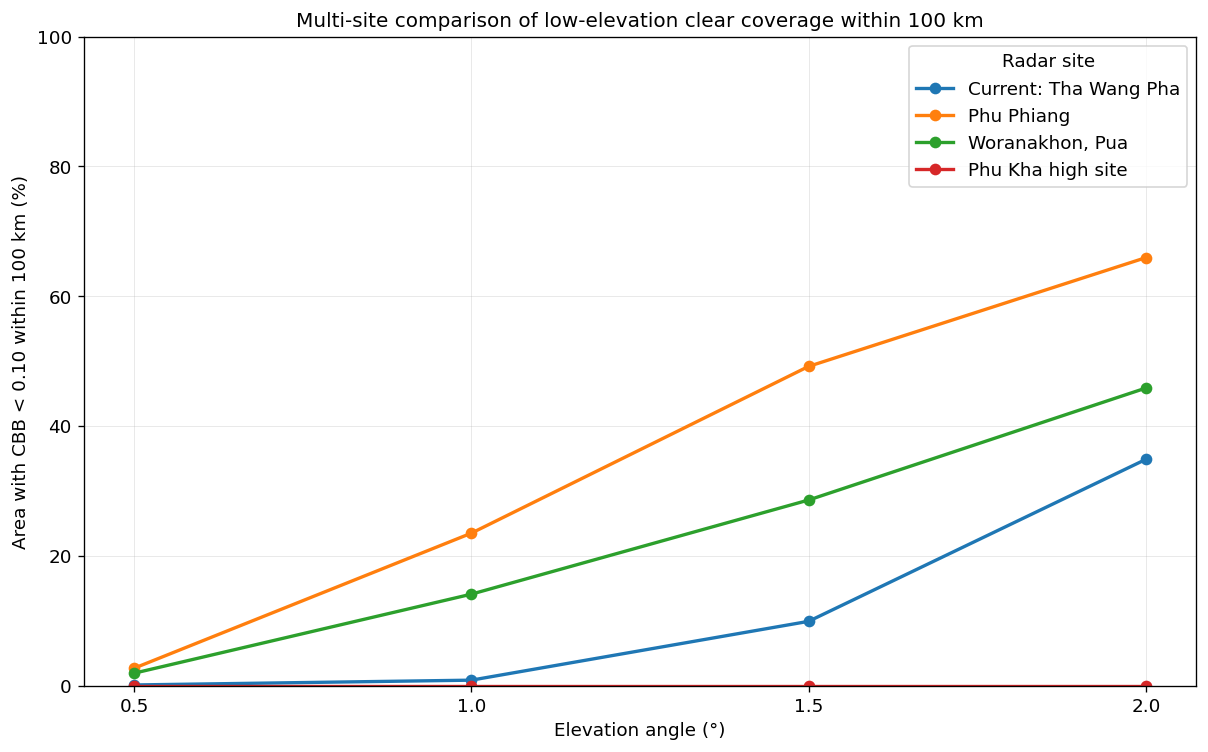

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_06_ClearArea_0_100km_by_Site_and_Elevation.png


In [19]:
# ============================================================
# STEP 16 — Figure 6: clear area within 100 km
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.2, 6.4)
)

for role in required_roles:
    sub = scenario_table[
        scenario_table[
            "site_role"
        ] == role
    ]

    ax.plot(
        sub["elevation_deg"],
        sub["clear_area_pct_0_100km"],
        marker="o",
        linewidth=2.0,
        label=display_name_from_role(role),
    )

ax.set_xticks(
    ELEVATIONS_DEG
)

ax.set_ylim(
    0,
    100,
)

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Area with CBB < 0.10 within 100 km (%)"
)

ax.set_title(
    "Multi-site comparison of low-elevation clear coverage within 100 km"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Radar site",
    loc="best",
)

fig.tight_layout()

fig6_path = (
    FIGURES_DIR /
    "Fig06_06_ClearArea_0_100km_by_Site_and_Elevation.png"
)

fig.savefig(
    fig6_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig6_path)

## 14. Figure 7 — Clear Area ภายใน 240 km

กราฟนี้แสดงภาพรวม coverage ทั้ง domain แต่ต้องตีความร่วมกับ beam altitude เพราะ elevation สูงอาจมี clear terrain visibility แต่ sample atmosphere สูงเกินไปสำหรับบางภารกิจ

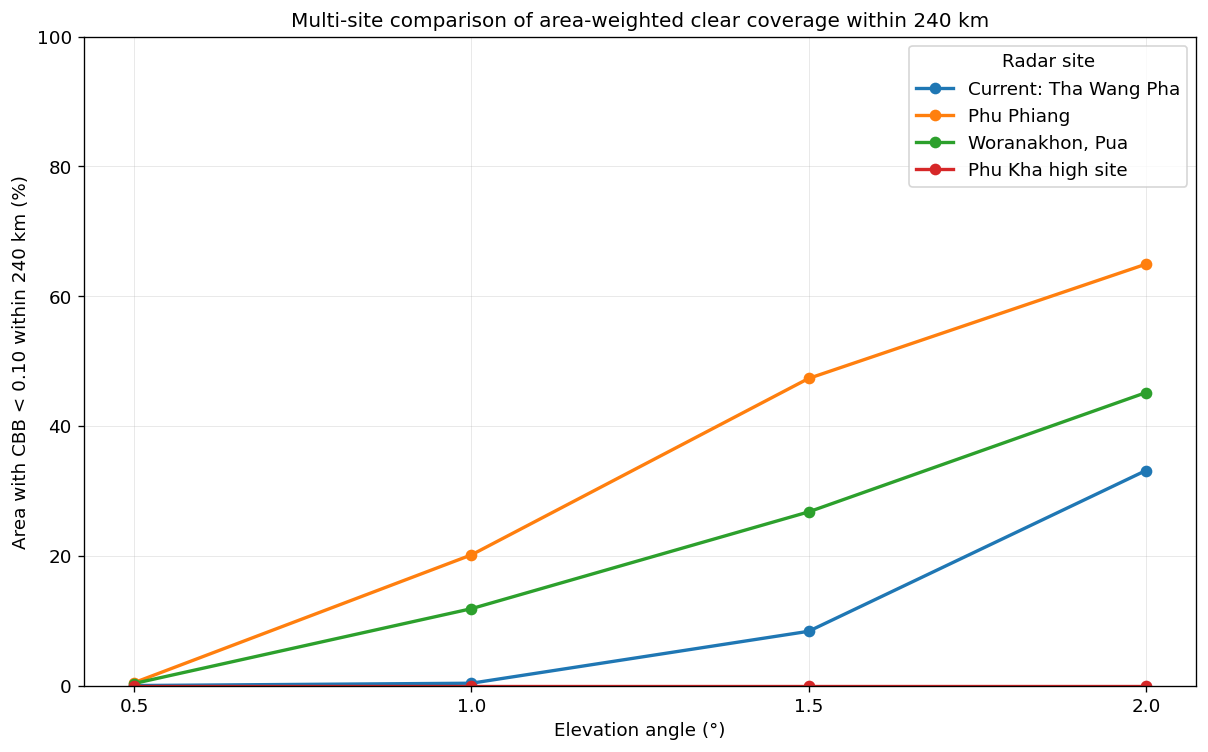

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_07_ClearArea_0_240km_by_Site_and_Elevation.png


In [20]:
# ============================================================
# STEP 17 — Figure 7: clear area within 240 km
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.2, 6.4)
)

for role in required_roles:
    sub = scenario_table[
        scenario_table[
            "site_role"
        ] == role
    ]

    ax.plot(
        sub["elevation_deg"],
        sub["clear_area_pct_0_240km"],
        marker="o",
        linewidth=2.0,
        label=display_name_from_role(role),
    )

ax.set_xticks(
    ELEVATIONS_DEG
)

ax.set_ylim(
    0,
    100,
)

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Area with CBB < 0.10 within 240 km (%)"
)

ax.set_title(
    "Multi-site comparison of area-weighted clear coverage within 240 km"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Radar site",
    loc="best",
)

fig.tight_layout()

fig7_path = (
    FIGURES_DIR /
    "Fig06_07_ClearArea_0_240km_by_Site_and_Elevation.png"
)

fig.savefig(
    fig7_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig7_path)

## 15. Figure 8 — Severe Blockage ภายใน 100 km

สำหรับ radar siting ค่า severe area ใน near-to-intermediate range มีความหมายเชิงปฏิบัติสูง

$$
CBB\ge0.50
$$

พื้นที่กลุ่มนี้ควรถูกพิจารณาร่วมกับ mission ของ radar

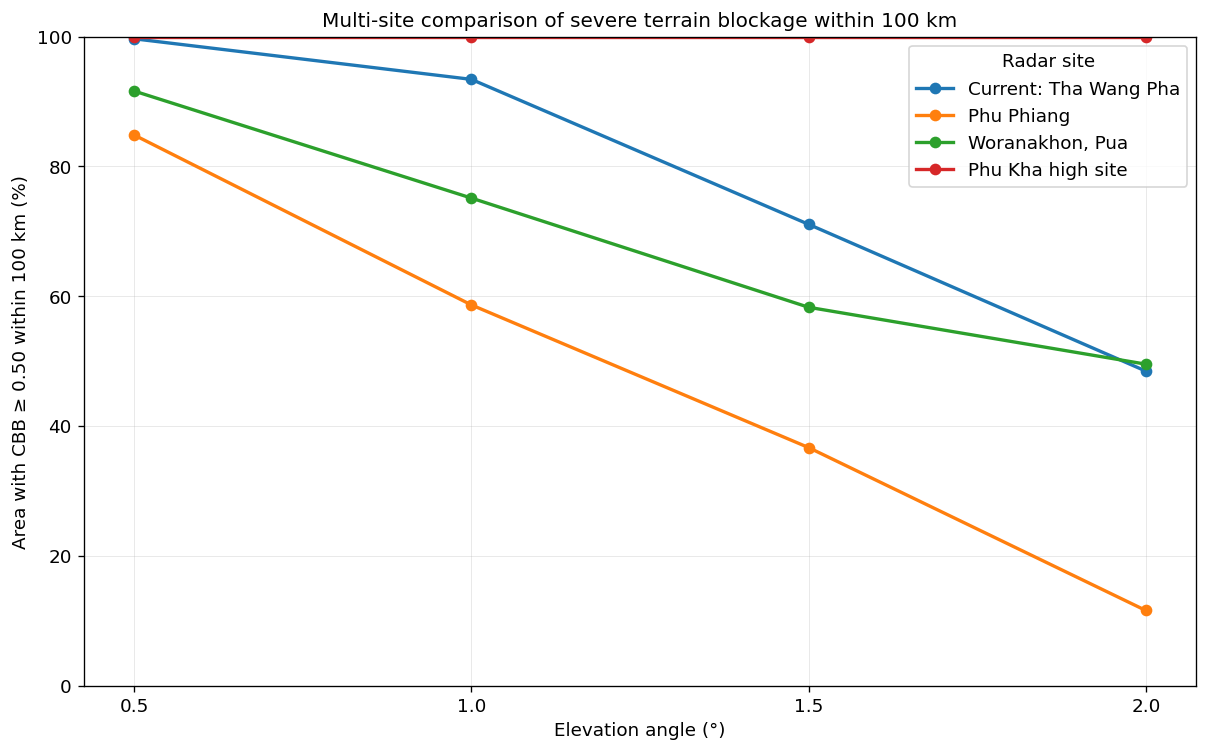

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_08_SevereArea_0_100km_by_Site_and_Elevation.png


In [21]:
# ============================================================
# STEP 18 — Figure 8: severe blockage within 100 km
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.2, 6.4)
)

for role in required_roles:
    sub = scenario_table[
        scenario_table[
            "site_role"
        ] == role
    ]

    ax.plot(
        sub["elevation_deg"],
        sub["severe_area_pct_0_100km"],
        marker="o",
        linewidth=2.0,
        label=display_name_from_role(role),
    )

ax.set_xticks(
    ELEVATIONS_DEG
)

ax.set_ylim(
    0,
    100,
)

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Area with CBB ≥ 0.50 within 100 km (%)"
)

ax.set_title(
    "Multi-site comparison of severe terrain blockage within 100 km"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Radar site",
    loc="best",
)

fig.tight_layout()

fig8_path = (
    FIGURES_DIR /
    "Fig06_08_SevereArea_0_100km_by_Site_and_Elevation.png"
)

fig.savefig(
    fig8_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig8_path)

# Part H — Clear Azimuth Fraction ณ Target Range

## 16. เหตุผล

Area-weighted coverage บอกภาพรวมพื้นที่

แต่ผู้ปฏิบัติงาน radar มักถามอีกแบบว่า

> ที่ระยะ 100 km มีทิศทางกี่เปอร์เซ็นต์ที่ยัง clear?

เราจึงคำนวณ clear/partial/severe fraction ของ 360 azimuths ที่ target ranges

In [22]:
# ============================================================
# STEP 19 — Azimuth visibility at target ranges
# ============================================================

target_rows = []

for _, site in sites.iterrows():
    role = site["site_role"]

    for elev in ELEVATIONS_DEG:
        cbb = results[
            role
        ][
            float(elev)
        ]["cbb"]

        for target_km in TARGET_RANGES_KM:
            idx = int(
                np.argmin(
                    np.abs(
                        RANGE_CENTERS_KM
                        - target_km
                    )
                )
            )

            values = cbb[
                :,
                idx
            ]

            valid = np.isfinite(
                values
            )

            n = int(
                valid.sum()
            )

            clear = (
                valid
                & (
                    values
                    < CLEAR_THRESHOLD
                )
            )

            partial = (
                valid
                & (
                    values
                    >= CLEAR_THRESHOLD
                )
                & (
                    values
                    < SEVERE_THRESHOLD
                )
            )

            severe = (
                valid
                & (
                    values
                    >= SEVERE_THRESHOLD
                )
            )

            target_rows.append({
                "site_role": role,
                "display_name": site["display_name"],
                "elevation_deg": elev,
                "target_range_km": target_km,
                "actual_gate_range_km": RANGE_CENTERS_KM[idx],
                "clear_azimuth_pct": 100.0 * clear.sum() / n,
                "partial_azimuth_pct": 100.0 * partial.sum() / n,
                "severe_azimuth_pct": 100.0 * severe.sum() / n,
            })

target_range_table = pd.DataFrame(
    target_rows
)

target_range_csv = (
    TABLES_DIR /
    "06_MultiSite_AzimuthVisibility_at_TargetRanges.csv"
)

target_range_table.to_csv(
    target_range_csv,
    index=False,
)

display(
    target_range_table.head(20).style.format({
        "elevation_deg": "{:.1f}",
        "target_range_km": "{:.0f}",
        "actual_gate_range_km": "{:.2f}",
        "clear_azimuth_pct": "{:.2f}",
        "partial_azimuth_pct": "{:.2f}",
        "severe_azimuth_pct": "{:.2f}",
    })
)

print("\nSaved:")
print(target_range_csv)

,site_role,display_name,elevation_deg,target_range_km,actual_gate_range_km,clear_azimuth_pct,partial_azimuth_pct,severe_azimuth_pct
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,50,49.75,0.00,0.00,100.00
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,100,99.75,0.00,0.00,100.00
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,150,149.75,0.00,0.00,100.00
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,200,199.75,0.00,0.00,100.00
4,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,240,239.75,0.00,0.00,100.00
5,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,50,49.75,0.28,5.28,94.44
6,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,100,99.75,0.28,5.28,94.44
7,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,150,149.75,0.28,5.28,94.44
8,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,200,199.75,0.28,5.28,94.44
9,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,240,239.75,0.28,5.28,94.44



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_AzimuthVisibility_at_TargetRanges.csv


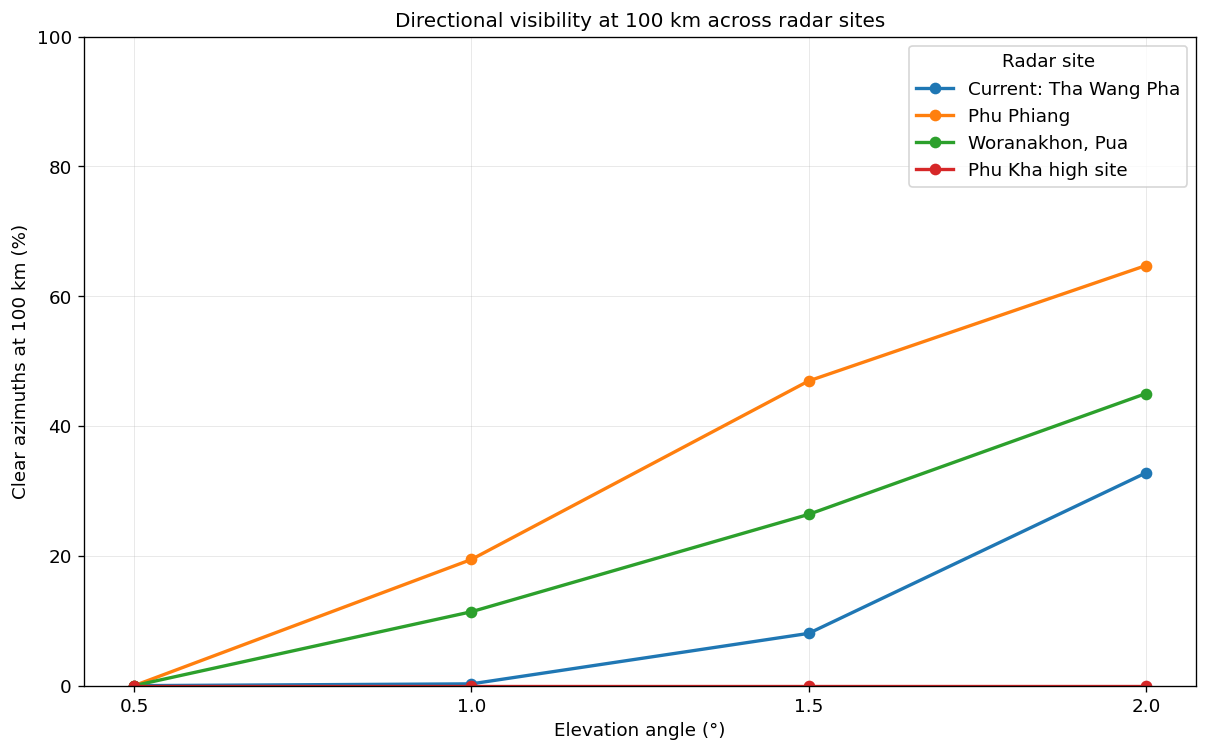

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_09_ClearAzimuth_at_100km_by_Site_and_Elevation.png


In [23]:
# ============================================================
# STEP 20 — Figure 9: clear azimuth percentage at 100 km
# ============================================================

target100 = target_range_table[
    target_range_table[
        "target_range_km"
    ] == 100
]

fig, ax = plt.subplots(
    figsize=(10.2, 6.4)
)

for role in required_roles:
    sub = target100[
        target100[
            "site_role"
        ] == role
    ]

    ax.plot(
        sub["elevation_deg"],
        sub["clear_azimuth_pct"],
        marker="o",
        linewidth=2.0,
        label=display_name_from_role(role),
    )

ax.set_xticks(
    ELEVATIONS_DEG
)

ax.set_ylim(
    0,
    100,
)

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Clear azimuths at 100 km (%)"
)

ax.set_title(
    "Directional visibility at 100 km across radar sites"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Radar site",
    loc="best",
)

fig.tight_layout()

fig9_path = (
    FIGURES_DIR /
    "Fig06_09_ClearAzimuth_at_100km_by_Site_and_Elevation.png"
)

fig.savefig(
    fig9_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig9_path)

# Part I — D10/D50 Across Sites

## 17. Directional Threshold Analysis

สำหรับแต่ละ site × elevation × azimuth จะบันทึก D10 และ D50

และสร้าง summary สองส่วน:

1. threshold reached ภายใน 240 km กี่เปอร์เซ็นต์
2. median distance เฉพาะ rays ที่ถึง threshold

In [24]:
# ============================================================
# STEP 21 — Compute D10/D50 for all azimuths
# ============================================================

threshold_rows = []

for _, site in sites.iterrows():
    role = site["site_role"]

    for elev in ELEVATIONS_DEG:
        cbb = results[
            role
        ][
            float(elev)
        ]["cbb"]

        for az in AZIMUTHS_DEG:
            ray = cbb[
                int(az),
                :
            ]

            threshold_rows.append({
                "site_role": role,
                "display_name": site["display_name"],
                "elevation_deg": elev,
                "azimuth_deg": az,
                "D10_km": first_threshold_distance_km(
                    ray,
                    CLEAR_THRESHOLD,
                ),
                "D50_km": first_threshold_distance_km(
                    ray,
                    SEVERE_THRESHOLD,
                ),
            })

threshold_table = pd.DataFrame(
    threshold_rows
)

threshold_csv = (
    TABLES_DIR /
    "06_MultiSite_D10_D50_All_Azimuths.csv"
)

threshold_table.to_csv(
    threshold_csv,
    index=False,
)

print("Saved:", threshold_csv)

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_D10_D50_All_Azimuths.csv


In [25]:
# ============================================================
# STEP 22 — Summarize censored D10/D50 behavior
# ============================================================

threshold_summary_rows = []

for role in required_roles:
    for elev in ELEVATIONS_DEG:
        sub = threshold_table[
            (
                threshold_table["site_role"]
                == role
            )
            & (
                threshold_table["elevation_deg"]
                == elev
            )
        ]

        d10 = sub["D10_km"]
        d50 = sub["D50_km"]

        d10_reached = d10.notna()
        d50_reached = d50.notna()

        threshold_summary_rows.append({
            "site_role": role,
            "display_name": display_name_from_role(role),
            "elevation_deg": elev,
            "D10_reached_pct": 100.0 * d10_reached.mean(),
            "D10_not_reached_pct": 100.0 * (~d10_reached).mean(),
            "median_D10_if_reached_km": (
                float(
                    d10[
                        d10_reached
                    ].median()
                )
                if d10_reached.any()
                else np.nan
            ),
            "D50_reached_pct": 100.0 * d50_reached.mean(),
            "D50_not_reached_pct": 100.0 * (~d50_reached).mean(),
            "median_D50_if_reached_km": (
                float(
                    d50[
                        d50_reached
                    ].median()
                )
                if d50_reached.any()
                else np.nan
            ),
        })

threshold_summary = pd.DataFrame(
    threshold_summary_rows
)

threshold_summary_csv = (
    TABLES_DIR /
    "06_MultiSite_D10_D50_Censored_Summary.csv"
)

threshold_summary.to_csv(
    threshold_summary_csv,
    index=False,
)

display(
    threshold_summary.style.format({
        "elevation_deg": "{:.1f}",
        "D10_reached_pct": "{:.1f}",
        "D10_not_reached_pct": "{:.1f}",
        "median_D10_if_reached_km": "{:.1f}",
        "D50_reached_pct": "{:.1f}",
        "D50_not_reached_pct": "{:.1f}",
        "median_D50_if_reached_km": "{:.1f}",
    })
)

print("\nSaved:")
print(threshold_summary_csv)

,site_role,display_name,elevation_deg,D10_reached_pct,D10_not_reached_pct,median_D10_if_reached_km,D50_reached_pct,D50_not_reached_pct,median_D50_if_reached_km
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5,100.0,0.0,1.8,100.0,0.0,2.2
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0,99.7,0.3,2.8,94.4,5.6,8.8
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5,91.9,8.1,10.8,73.3,26.7,15.2
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0,67.2,32.8,15.5,50.0,50.0,16.2
4,PHU_PHIANG,Phu Phiang,0.5,100.0,0.0,8.2,89.2,10.8,15.2
5,PHU_PHIANG,Phu Phiang,1.0,80.6,19.4,16.0,62.2,37.8,15.5
6,PHU_PHIANG,Phu Phiang,1.5,53.1,46.9,7.2,38.1,61.9,6.2
7,PHU_PHIANG,Phu Phiang,2.0,35.3,64.7,6.8,11.7,88.3,5.8
8,WORANAKHON_PUA,"Woranakhon, Pua",0.5,100.0,0.0,9.8,94.7,5.3,10.8
9,WORANAKHON_PUA,"Woranakhon, Pua",1.0,88.6,11.4,8.8,77.5,22.5,7.2



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_D10_D50_Censored_Summary.csv


## 18. Figure 10 — Azimuths ที่ D10 ไม่ถึงภายใน 240 km

ค่านี้อ่านง่ายมาก:

ยิ่งสูง หมายถึงมี azimuths มากขึ้นที่

$$
CBB<0.10
$$

ตลอด analysis range

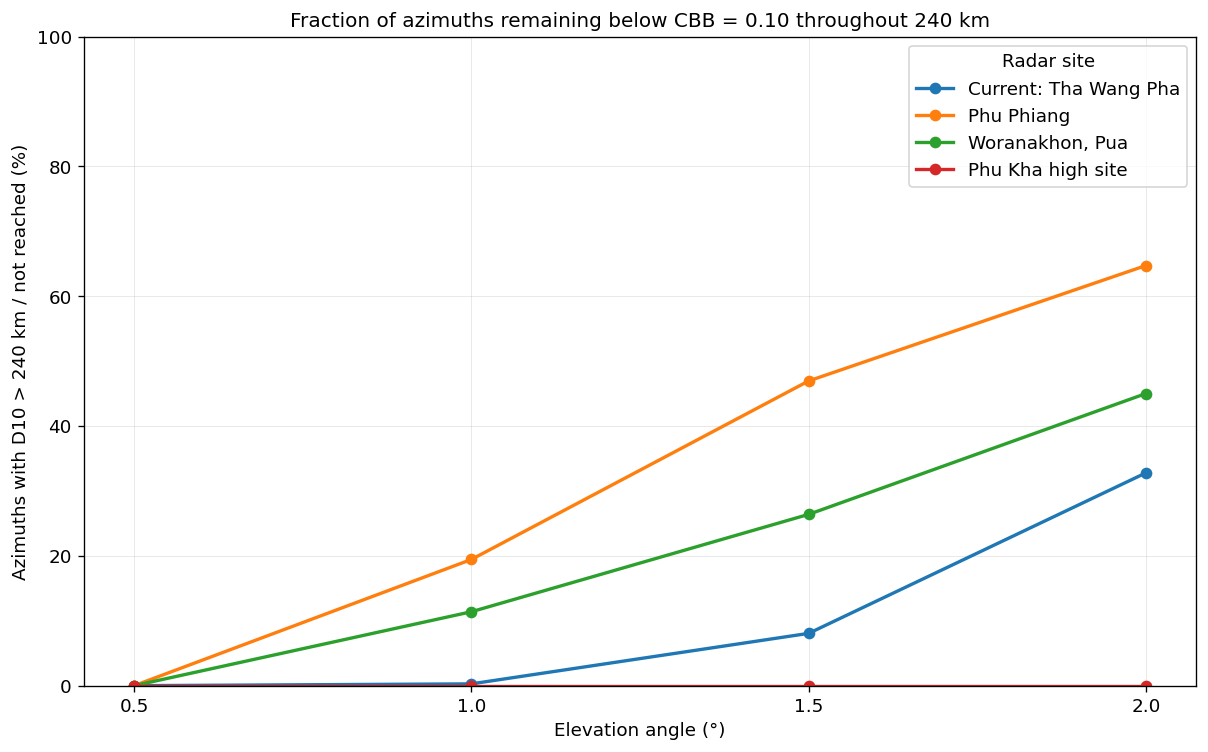

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_10_D10_NotReached_by_Site_and_Elevation.png


In [26]:
# ============================================================
# STEP 23 — Figure 10: D10 not reached within 240 km
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.2, 6.4)
)

for role in required_roles:
    sub = threshold_summary[
        threshold_summary[
            "site_role"
        ] == role
    ]

    ax.plot(
        sub["elevation_deg"],
        sub["D10_not_reached_pct"],
        marker="o",
        linewidth=2.0,
        label=display_name_from_role(role),
    )

ax.set_xticks(
    ELEVATIONS_DEG
)

ax.set_ylim(
    0,
    100,
)

ax.set_xlabel(
    "Elevation angle (°)"
)

ax.set_ylabel(
    "Azimuths with D10 > 240 km / not reached (%)"
)

ax.set_title(
    "Fraction of azimuths remaining below CBB = 0.10 throughout 240 km"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Radar site",
    loc="best",
)

fig.tight_layout()

fig10_path = (
    FIGURES_DIR /
    "Fig06_10_D10_NotReached_by_Site_and_Elevation.png"
)

fig.savefig(
    fig10_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig10_path)

# Part J — Multi-Site Minimum Usable Elevation

## 19. MUE Distribution

สำหรับแต่ละ site เราสร้าง MUE จาก elevations ชุดเดียวกัน

$$
0.5^\circ,\;
1.0^\circ,\;
1.5^\circ,\;
2.0^\circ
$$

แล้วสรุปเป็น **area-weighted class distribution**

การเปรียบเทียบนี้ช่วยตอบว่า site ใดสามารถใช้ low sweep ได้ในพื้นที่มากกว่า

In [27]:
# ============================================================
# STEP 24 — Compute area-weighted MUE distribution for each site
# ============================================================

mue_by_site = {}
mue_rows = []

for _, site in sites.iterrows():
    role = site["site_role"]

    cbb_stack = np.stack(
        [
            results[
                role
            ][
                float(elev)
            ]["cbb"]
            for elev in ELEVATIONS_DEG
        ],
        axis=0,
    )

    common_valid = np.isfinite(
        cbb_stack
    ).all(
        axis=0
    )

    clear_stack = (
        np.isfinite(
            cbb_stack
        )
        & (
            cbb_stack
            < CLEAR_THRESHOLD
        )
    )

    mue = np.full(
        (NRAYS, NBINS),
        np.nan,
        dtype=np.float32,
    )

    for elev_index, elev in enumerate(
        ELEVATIONS_DEG
    ):
        assign = (
            common_valid
            & np.isnan(mue)
            & clear_stack[
                elev_index
            ]
        )

        mue[
            assign
        ] = elev

    mue_by_site[
        role
    ] = mue

    total_area = float(
        area_weights_m2[
            common_valid
        ].sum()
    )

    for elev in ELEVATIONS_DEG:
        mask = (
            common_valid
            & (
                mue
                == elev
            )
        )

        area = float(
            area_weights_m2[
                mask
            ].sum()
        )

        mue_rows.append({
            "site_role": role,
            "display_name": site["display_name"],
            "MUE_class": f"{elev:.1f}°",
            "area_km2": area / 1e6,
            "area_pct": 100.0 * area / total_area,
        })

    never = (
        common_valid
        & np.isnan(
            mue
        )
    )

    area_never = float(
        area_weights_m2[
            never
        ].sum()
    )

    mue_rows.append({
        "site_role": role,
        "display_name": site["display_name"],
        "MUE_class": "Not clear at 0.5–2.0°",
        "area_km2": area_never / 1e6,
        "area_pct": 100.0 * area_never / total_area,
    })

mue_summary = pd.DataFrame(
    mue_rows
)

mue_csv = (
    TABLES_DIR /
    "06_MultiSite_MUE_AreaWeighted_Summary.csv"
)

mue_summary.to_csv(
    mue_csv,
    index=False,
)

display(
    mue_summary.style.format({
        "area_km2": "{:,.1f}",
        "area_pct": "{:.2f}",
    })
)

print("\nSaved:")
print(mue_csv)

,site_role,display_name,MUE_class,area_km2,area_pct
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,0.5°,34.0,0.02
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.0°,647.9,0.36
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,1.5°,"14,478.2",8.00
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,2.0°,"44,808.9",24.76
4,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,Not clear at 0.5–2.0°,"120,986.8",66.86
5,PHU_PHIANG,Phu Phiang,0.5°,845.3,0.47
6,PHU_PHIANG,Phu Phiang,1.0°,"35,613.4",19.68
7,PHU_PHIANG,Phu Phiang,1.5°,"49,194.7",27.19
8,PHU_PHIANG,Phu Phiang,2.0°,"31,848.6",17.60
9,PHU_PHIANG,Phu Phiang,Not clear at 0.5–2.0°,"63,453.7",35.07



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_MUE_AreaWeighted_Summary.csv


## 20. Figure 11 — MUE Area Composition

พื้นที่ที่มี MUE = 0.5° มาก แสดงว่า low-elevation sweep สามารถใช้งานได้ในพื้นที่ส่วนใหญ่

ส่วน `Not clear at 0.5–2.0°` แสดงพื้นที่ที่ยังไม่ผ่านเกณฑ์ CBB < 0.10 แม้ยกถึง 2°

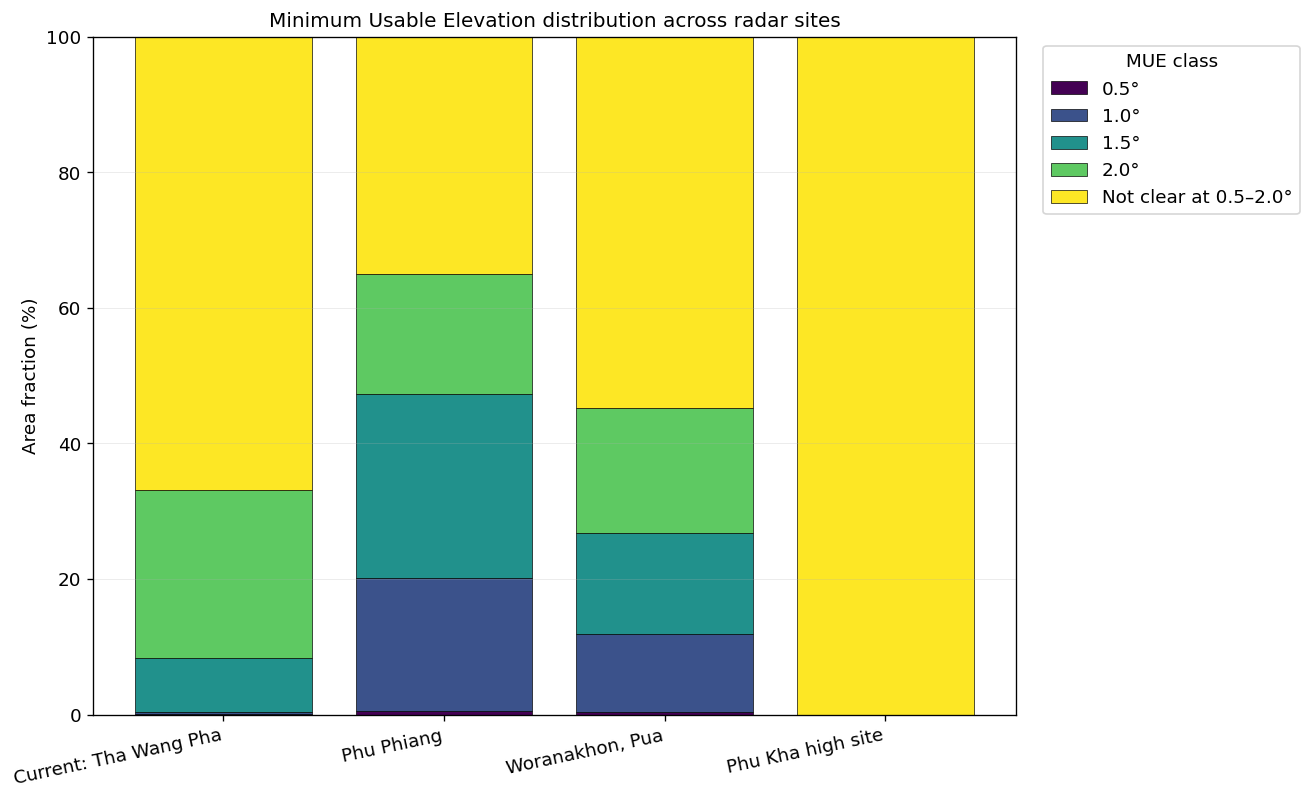

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_11_MUE_AreaComposition_by_Site.png


In [28]:
# ============================================================
# STEP 25 — Figure 11: stacked MUE area composition
# ============================================================

mue_classes = [
    "0.5°",
    "1.0°",
    "1.5°",
    "2.0°",
    "Not clear at 0.5–2.0°",
]

site_labels = [
    display_name_from_role(
        role
    )
    for role in required_roles
]

x = np.arange(
    len(required_roles)
)

bottom = np.zeros(
    len(required_roles),
    dtype=float,
)

fig, ax = plt.subplots(
    figsize=(11.0, 6.8)
)

mue_cmap = mpl.colormaps[
    "viridis"
].resampled(
    len(mue_classes)
)

for class_index, mue_class in enumerate(
    mue_classes
):
    values = []

    for role in required_roles:
        sub = mue_summary[
            (
                mue_summary["site_role"]
                == role
            )
            & (
                mue_summary["MUE_class"]
                == mue_class
            )
        ]

        values.append(
            float(
                sub.iloc[0]["area_pct"]
            )
        )

    values = np.asarray(
        values
    )

    ax.bar(
        x,
        values,
        bottom=bottom,
        label=mue_class,
        color=mue_cmap(
            class_index
        ),
        edgecolor="black",
        linewidth=0.4,
    )

    bottom += values

ax.set_xticks(
    x,
    site_labels,
    rotation=12,
    ha="right",
)

ax.set_ylim(
    0,
    100,
)

ax.set_ylabel(
    "Area fraction (%)"
)

ax.set_title(
    "Minimum Usable Elevation distribution across radar sites"
)

ax.legend(
    title="MUE class",
    bbox_to_anchor=(
        1.02,
        1.0,
    ),
    loc="upper left",
)

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.35,
)

fig.tight_layout()

fig11_path = (
    FIGURES_DIR /
    "Fig06_11_MUE_AreaComposition_by_Site.png"
)

fig.savefig(
    fig11_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig11_path)

# Part K — Phu Phiang vs Current Tha Wang Pha

## 21. Improvement Metrics

เพื่อทดสอบ working hypothesis โดยตรง เราคำนวณ

$$
\Delta A_{\mathrm{clear}}
=
A_{\mathrm{clear,PhuPhiang}}
-
A_{\mathrm{clear,Current}}
$$

ค่าเป็นบวก หมายถึง Phu Phiang มี clear-area percentage สูงกว่า

และ

$$
\Delta A_{\mathrm{severe}}
=
A_{\mathrm{severe,PhuPhiang}}
-
A_{\mathrm{severe,Current}}
$$

ค่าติดลบหมายถึง Phu Phiang มี severe blockage ต่ำกว่า

In [29]:
# ============================================================
# STEP 26 — Phu Phiang improvement relative to current
# ============================================================

current_band = area_band_table[
    area_band_table[
        "site_role"
    ] == "CURRENT_THA_WANG_PHA"
][
    [
        "elevation_deg",
        "range_band_km",
        "clear_area_pct",
        "partial_area_pct",
        "severe_area_pct",
    ]
].copy()

current_band = current_band.rename(
    columns={
        "clear_area_pct": "current_clear_area_pct",
        "partial_area_pct": "current_partial_area_pct",
        "severe_area_pct": "current_severe_area_pct",
    }
)

phu_band = area_band_table[
    area_band_table[
        "site_role"
    ] == "PHU_PHIANG"
][
    [
        "elevation_deg",
        "range_band_km",
        "clear_area_pct",
        "partial_area_pct",
        "severe_area_pct",
    ]
].copy()

phu_band = phu_band.rename(
    columns={
        "clear_area_pct": "phuphiang_clear_area_pct",
        "partial_area_pct": "phuphiang_partial_area_pct",
        "severe_area_pct": "phuphiang_severe_area_pct",
    }
)

improvement_table = phu_band.merge(
    current_band,
    on=[
        "elevation_deg",
        "range_band_km",
    ],
    how="inner",
)

improvement_table[
    "delta_clear_area_pct_point"
] = (
    improvement_table[
        "phuphiang_clear_area_pct"
    ]
    - improvement_table[
        "current_clear_area_pct"
    ]
)

improvement_table[
    "delta_severe_area_pct_point"
] = (
    improvement_table[
        "phuphiang_severe_area_pct"
    ]
    - improvement_table[
        "current_severe_area_pct"
    ]
)

improvement_csv = (
    TABLES_DIR /
    "06_PhuPhiang_minus_Current_AreaCoverage_Improvement.csv"
)

improvement_table.to_csv(
    improvement_csv,
    index=False,
)

display(
    improvement_table.style.format({
        "elevation_deg": "{:.1f}",
        "phuphiang_clear_area_pct": "{:.2f}",
        "current_clear_area_pct": "{:.2f}",
        "delta_clear_area_pct_point": "{:+.2f}",
        "phuphiang_severe_area_pct": "{:.2f}",
        "current_severe_area_pct": "{:.2f}",
        "delta_severe_area_pct_point": "{:+.2f}",
    })
)

print("\nSaved:")
print(improvement_csv)

,elevation_deg,range_band_km,phuphiang_clear_area_pct,phuphiang_partial_area_pct,phuphiang_severe_area_pct,current_clear_area_pct,current_partial_area_pct,current_severe_area_pct,delta_clear_area_pct_point,delta_severe_area_pct_point
0,0.5,0-50,10.70,16.090611,73.20,0.43,0.917972,98.65,+10.27,-25.44
1,0.5,50-100,0.02,11.264593,88.72,0.00,0.000000,100.00,+0.02,-11.28
2,0.5,100-150,0.00,10.833333,89.17,0.00,0.000000,100.00,+0.00,-10.83
3,0.5,150-200,0.00,10.833333,89.17,0.00,0.000000,100.00,+0.00,-10.83
4,0.5,200-240,0.00,10.833333,89.17,0.00,0.000000,100.00,+0.00,-10.83
5,1.0,0-50,34.98,16.372917,48.64,2.56,7.132333,90.31,+32.42,-41.66
6,1.0,50-100,19.67,18.334546,62.00,0.28,5.277778,94.44,+19.39,-32.45
7,1.0,100-150,19.44,18.333333,62.22,0.28,5.277778,94.44,+19.17,-32.22
8,1.0,150-200,19.44,18.333333,62.22,0.28,5.277778,94.44,+19.17,-32.22
9,1.0,200-240,19.44,18.333333,62.22,0.28,5.277778,94.44,+19.17,-32.22



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_PhuPhiang_minus_Current_AreaCoverage_Improvement.csv


## 22. Figure 12 — Clear-Area Improvement ของ Phu Phiang

แกนตั้งคือ percentage-point difference

$$
\Delta A_{\mathrm{clear}}
$$

เส้นเหนือศูนย์หมายถึง Phu Phiang ให้ clear coverage มากกว่าสถานีปัจจุบันใน range band นั้น

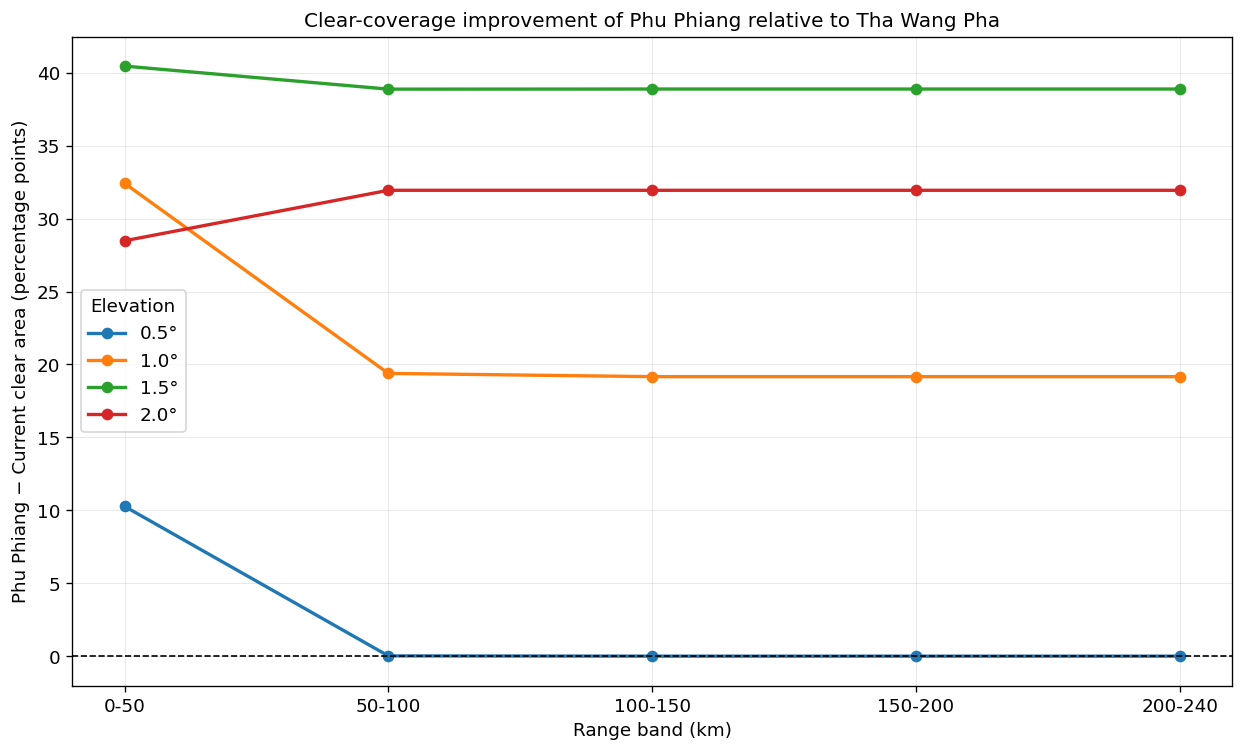

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig06_12_PhuPhiang_ClearArea_Improvement_vs_Current.png


In [30]:
# ============================================================
# STEP 27 — Figure 12: Phu Phiang clear-area improvement
# ============================================================

fig, ax = plt.subplots(
    figsize=(10.5, 6.4)
)

for elev in ELEVATIONS_DEG:
    sub = improvement_table[
        improvement_table[
            "elevation_deg"
        ] == elev
    ]

    ax.plot(
        sub["range_band_km"],
        sub[
            "delta_clear_area_pct_point"
        ],
        marker="o",
        linewidth=2.0,
        label=f"{elev:.1f}°",
    )

ax.axhline(
    0.0,
    color="black",
    linewidth=1.0,
    linestyle="--",
)

ax.set_xlabel(
    "Range band (km)"
)

ax.set_ylabel(
    "Phu Phiang − Current clear area (percentage points)"
)

ax.set_title(
    "Clear-coverage improvement of Phu Phiang relative to Tha Wang Pha"
)

ax.grid(
    True,
    linewidth=0.4,
    alpha=0.4,
)

ax.legend(
    title="Elevation",
    loc="best",
)

fig.tight_layout()

fig12_path = (
    FIGURES_DIR /
    "Fig06_12_PhuPhiang_ClearArea_Improvement_vs_Current.png"
)

fig.savefig(
    fig12_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig12_path)

# Part L — Key Comparison Table

## 23. สรุป Metrics ที่ควรใช้ในการอภิปราย

ตารางถัดไปดึงเฉพาะ metrics ที่ตีความง่ายสำหรับ radar siting:

- clear area 0–100 km
- severe area 0–100 km
- clear area 0–240 km
- clear azimuths at 100 km
- D10 not reached percentage
- D50 not reached percentage

In [31]:
# ============================================================
# STEP 28 — Build compact site-comparison table
# ============================================================

d10d50_small = threshold_summary[
    [
        "site_role",
        "elevation_deg",
        "D10_not_reached_pct",
        "D50_not_reached_pct",
        "median_D10_if_reached_km",
        "median_D50_if_reached_km",
    ]
].copy()

target100_small = target100[
    [
        "site_role",
        "elevation_deg",
        "clear_azimuth_pct",
        "severe_azimuth_pct",
    ]
].copy()

key_table = (
    scenario_table
    .merge(
        d10d50_small,
        on=[
            "site_role",
            "elevation_deg",
        ],
        how="left",
    )
    .merge(
        target100_small,
        on=[
            "site_role",
            "elevation_deg",
        ],
        how="left",
    )
)

key_columns = [
    "site_role",
    "display_name",
    "ground_elevation_msl_m",
    "elevation_deg",
    "clear_area_pct_0_100km",
    "severe_area_pct_0_100km",
    "clear_area_pct_0_240km",
    "clear_azimuth_pct",
    "severe_azimuth_pct",
    "D10_not_reached_pct",
    "D50_not_reached_pct",
    "median_D10_if_reached_km",
    "median_D50_if_reached_km",
]

key_table = key_table[
    key_columns
]

key_table_csv = (
    TABLES_DIR /
    "06_MultiSite_Key_Radar_Visibility_Metrics.csv"
)

key_table.to_csv(
    key_table_csv,
    index=False,
)

display(
    key_table.style.format({
        "ground_elevation_msl_m": "{:.1f}",
        "elevation_deg": "{:.1f}",
        "clear_area_pct_0_100km": "{:.2f}",
        "severe_area_pct_0_100km": "{:.2f}",
        "clear_area_pct_0_240km": "{:.2f}",
        "clear_azimuth_pct": "{:.2f}",
        "severe_azimuth_pct": "{:.2f}",
        "D10_not_reached_pct": "{:.2f}",
        "D50_not_reached_pct": "{:.2f}",
        "median_D10_if_reached_km": "{:.1f}",
        "median_D50_if_reached_km": "{:.1f}",
    })
)

print("\nSaved:")
print(key_table_csv)

,site_role,display_name,ground_elevation_msl_m,elevation_deg,clear_area_pct_0_100km,severe_area_pct_0_100km,clear_area_pct_0_240km,clear_azimuth_pct,severe_azimuth_pct,D10_not_reached_pct,D50_not_reached_pct,median_D10_if_reached_km,median_D50_if_reached_km
0,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,0.5,0.11,99.66,0.02,0.00,100.00,0.00,0.00,1.8,2.2
1,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,1.0,0.85,93.41,0.38,0.28,94.44,0.28,5.56,2.8,8.8
2,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,1.5,9.91,71.08,8.38,8.06,73.33,8.06,26.67,10.8,15.2
3,CURRENT_THA_WANG_PHA,Current: Tha Wang Pha,233.0,2.0,34.86,48.47,33.14,32.78,50.00,32.78,50.00,15.5,16.2
4,PHU_PHIANG,Phu Phiang,235.0,0.5,2.69,84.84,0.47,0.00,89.17,0.00,10.83,8.2,15.2
5,PHU_PHIANG,Phu Phiang,235.0,1.0,23.50,58.66,20.15,19.44,62.22,19.44,37.78,16.0,15.5
6,PHU_PHIANG,Phu Phiang,235.0,1.5,49.19,36.68,47.33,46.94,38.06,46.94,61.94,7.2,6.2
7,PHU_PHIANG,Phu Phiang,235.0,2.0,65.94,11.58,64.93,64.72,11.67,64.72,88.33,6.8,5.8
8,WORANAKHON_PUA,"Woranakhon, Pua",347.0,0.5,1.92,91.61,0.33,0.00,94.72,0.00,5.28,9.8,10.8
9,WORANAKHON_PUA,"Woranakhon, Pua",347.0,1.0,14.10,75.12,11.86,11.39,77.50,11.39,22.50,8.8,7.2



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_Key_Radar_Visibility_Metrics.csv


In [32]:
# ============================================================
# STEP 29 — Save compact multi-site CBB stack
# ============================================================

site_roles = np.array(
    required_roles,
    dtype=object,
)

site_names = np.array(
    [
        display_name_from_role(role)
        for role in required_roles
    ],
    dtype=object,
)

cbb_stack = np.stack(
    [
        np.stack(
            [
                results[
                    role
                ][
                    float(elev)
                ]["cbb"]
                for elev in ELEVATIONS_DEG
            ],
            axis=0,
        )
        for role in required_roles
    ],
    axis=0,
).astype(
    np.float32
)

mue_stack = np.stack(
    [
        mue_by_site[
            role
        ]
        for role in required_roles
    ],
    axis=0,
).astype(
    np.float32
)

array_output = (
    RESULTS_DIR /
    "06_MultiSite_CBB_4sites_4elevations.npz"
)

np.savez_compressed(
    array_output,
    site_roles=site_roles,
    site_names=site_names,
    elevations_deg=ELEVATIONS_DEG,
    azimuth_deg=AZIMUTHS_DEG,
    range_centers_m=RANGE_CENTERS_M,
    cbb=cbb_stack,
    mue_deg=mue_stack,
)

print("Saved:")
print(array_output)
print(
    "CBB stack shape:",
    cbb_stack.shape
)
print(
    "MUE stack shape:",
    mue_stack.shape
)
print(
    "File size:",
    f"{array_output.stat().st_size/1024**2:.2f} MB"
)

Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/06_MultiSite_CBB_4sites_4elevations.npz
CBB stack shape: (4, 4, 360, 480)
MUE stack shape: (4, 360, 480)
File size: 0.06 MB


# Part M — การตีความเชิงวิชาการ

## 24. ถ้า Phu Phiang ดีกว่า Current ควรเห็นอะไร?

ภายใต้ working hypothesis เราควรเห็นอย่างน้อยบางข้อดังนี้

- clear area 0–100 km สูงกว่า
- severe area 0–100 km ต่ำกว่า
- clear azimuth fraction ที่ 100 km สูงกว่า
- D10 not reached percentage สูงกว่า
- MUE = 0.5° หรือ 1.0° ครอบคลุมพื้นที่มากกว่า
- $\Delta A_{\mathrm{clear}}>0$ ใน range bands ที่สำคัญ

แต่ไม่จำเป็นต้องดีกว่าทุก metric หรือทุก elevation

site selection จึงเป็น **multi-criteria problem**

## 25. High-Mountain Site ต้องตีความต่างออกไป

Phu Kha high site มี ground elevation สูงมากกว่าสถานีอื่น

จึงอาจมีข้อได้เปรียบในการหลบ terrain บางทิศ แต่ beam absolute altitude จะสูงขึ้นตั้งแต่ต้น

ดังนั้น site ที่มี terrain visibility ดีที่สุดอาจไม่ใช่ site ที่เหมาะที่สุดสำหรับ

- low-level QPE
- shallow precipitation
- flash-flood rainfall monitoring

นี่เป็นเหตุผลที่ Notebook 07 จะไม่จัดอันดับจาก CBB เพียง metric เดียว

## 26. ข้อจำกัดของ 1-km MAX DEM

ผล near-range โดยเฉพาะ $0.5^\circ$ ยังต้องระวัง

เพราะ 1-km MAX DEM มีแนวโน้มรักษายอด terrain สูงสุดในแต่ละ cell และอาจทำให้ near-field obstruction ดูรุนแรงกว่าการใช้ DEM ละเอียด

ดังนั้นผล Notebook 06 เหมาะสำหรับ

> **regional screening และ relative site comparison**

แต่ก่อน final engineering recommendation ควรทำ sensitivity test ด้วย high-resolution local DEM และ actual tower/antenna height

## 27. แบบฝึกคิด

### CORE

1. site ใดให้ clear area 0–100 km สูงที่สุดที่ 0.5°?
2. site ใดมี severe blockage ต่ำที่สุดที่ 1.0°?
3. Phu Phiang ดีกว่า current กี่ percentage points ในแต่ละ range band?
4. site ใดมี azimuths ที่ D10 ไม่ถึงภายใน 240 km มากที่สุด?

### ADVANCED

5. เปรียบเทียบ Phu Phiang กับ Woranakhon ว่า improvement เกิดจาก terrain setting หรือ site elevation มากกว่ากันอย่างไร
6. อธิบายว่าเหตุใด high-mountain site อาจมี CBB ต่ำแต่ไม่เหมาะกับ QPE
7. หา elevation ที่ทำให้ ranking ของ sites เปลี่ยน

### RESEARCH EXTENSION

8. เสนอ weighting scheme สำหรับภารกิจ QPE ภายใน 100 km
9. เสนอวิธี regrid CBB ของทุก site ลงบน common Cartesian grid
10. ออกแบบ sensitivity experiment สำหรับ antenna heights 20, 30, 50 และ 100 m AGL

In [33]:
# ============================================================
# STEP 30 — Save metadata and final readiness check
# ============================================================

metadata = {
    "notebook": (
        "06_Multi_Site_Radar_Terrain_Visibility_Comparison"
    ),
    "site_identity_strategy": (
        "Place-based roles inferred from site_name/status; "
        "original site_id retained for traceability."
    ),
    "site_roles": {
        str(row["site_role"]): {
            "site_id": str(row["site_id"]),
            "site_name": str(row["site_name"]),
            "ground_elevation_msl_m": float(
                row["native_dem_m"]
            ),
        }
        for _, row in sites.iterrows()
    },
    "working_hypothesis": (
        "Phu Phiang provides improved low-elevation terrain "
        "visibility relative to current Tha Wang Pha, "
        "especially within 0–100 km."
    ),
    "elevations_deg": ELEVATIONS_DEG.tolist(),
    "beamwidth_deg": BEAMWIDTH_DEG,
    "k_factor": K_STANDARD,
    "earth_radius_m": EARTH_RADIUS_M,
    "antenna_agl_teaching_assumption_m": ANTENNA_AGL_M,
    "range_resolution_m": RANGE_RES_M,
    "maximum_range_km": MAX_RANGE_M / 1000.0,
    "azimuth_spacing_deg": 1.0,
    "clear_threshold": CLEAR_THRESHOLD,
    "severe_threshold": SEVERE_THRESHOLD,
    "area_weighting": (
        "Nominal planar annular-sector area."
    ),
    "cross_site_spatial_difference_warning": (
        "Do not subtract site CBB arrays by polar index because "
        "different radar origins sample different ground locations."
    ),
    "dem_path": str(
        DEM_PATH
    ),
    "wradlib_version": wrl.__version__,
    "array_output": str(
        array_output
    ),
    "scenario_summary_csv": str(
        scenario_csv
    ),
    "area_band_csv": str(
        area_band_csv
    ),
    "target_range_csv": str(
        target_range_csv
    ),
    "threshold_csv": str(
        threshold_csv
    ),
    "threshold_summary_csv": str(
        threshold_summary_csv
    ),
    "mue_csv": str(
        mue_csv
    ),
    "phuphiang_improvement_csv": str(
        improvement_csv
    ),
    "key_metrics_csv": str(
        key_table_csv
    ),
}

metadata_path = (
    METADATA_DIR /
    "06_MultiSite_Radar_Visibility_Metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

all_valid = bool(
    (
        qc_table[
            "valid_terrain_pct"
        ]
        >= 99.0
    ).all()
)

all_pbb_valid = bool(
    (
        qc_table[
            "pbb_min"
        ]
        >= 0.0
    ).all()
    and
    (
        qc_table[
            "pbb_max"
        ]
        <= 1.0
    ).all()
)

all_cbb_valid = bool(
    (
        qc_table[
            "cbb_min"
        ]
        >= 0.0
    ).all()
    and
    (
        qc_table[
            "cbb_max"
        ]
        <= 1.0
    ).all()
)

all_monotonic = bool(
    qc_table[
        "cbb_monotonic_complete_rays"
    ].all()
)

final_checks = {
    "Four place-based site roles resolved": (
        len(sites) == 4
    ),
    "16 scenarios calculated": (
        sum(
            len(results[role])
            for role in required_roles
        )
        == 16
    ),
    "≥99% terrain coverage in all scenarios": all_valid,
    "All PBB values within 0–1": all_pbb_valid,
    "All CBB values within 0–1": all_cbb_valid,
    "CBB monotonic along complete rays": all_monotonic,
    "Scenario summary saved": scenario_csv.exists(),
    "Range-band summary saved": area_band_csv.exists(),
    "Target-range visibility saved": target_range_csv.exists(),
    "D10/D50 outputs saved": (
        threshold_csv.exists()
        and threshold_summary_csv.exists()
    ),
    "MUE summary saved": mue_csv.exists(),
    "Phu Phiang improvement table saved": improvement_csv.exists(),
    "Key metrics table saved": key_table_csv.exists(),
    "Compact CBB stack saved": array_output.exists(),
    "Metadata JSON saved": metadata_path.exists(),
}

print("=" * 92)
print("NOTEBOOK 06 — FINAL READINESS CHECK")
print("=" * 92)

all_ok = True

for label, status in final_checks.items():
    print(
        ("✓" if status else "✗"),
        label,
    )
    all_ok = all_ok and status

print("=" * 92)

print("\nKey outputs")
print("-----------")
print("Scenario metrics :", scenario_csv)
print("Range bands      :", area_band_csv)
print("Target ranges    :", target_range_csv)
print("D10/D50          :", threshold_summary_csv)
print("MUE              :", mue_csv)
print("Phu vs Current   :", improvement_csv)
print("Key metrics      :", key_table_csv)
print("CBB stack        :", array_output)
print("Metadata         :", metadata_path)

if all_ok:
    print(
        "\n✓ MULTI-SITE COMPARISON READY — proceed to "
        "Notebook 07: Radar Site Decision Support and "
        "Common-Domain Spatial Evaluation."
    )
else:
    raise RuntimeError(
        "One or more Notebook 06 QC checks failed."
    )

NOTEBOOK 06 — FINAL READINESS CHECK
✓ Four place-based site roles resolved
✓ 16 scenarios calculated
✓ ≥99% terrain coverage in all scenarios
✓ All PBB values within 0–1
✓ All CBB values within 0–1
✓ CBB monotonic along complete rays
✓ Scenario summary saved
✓ Range-band summary saved
✓ Target-range visibility saved
✓ D10/D50 outputs saved
✓ MUE summary saved
✓ Phu Phiang improvement table saved
✓ Key metrics table saved
✓ Compact CBB stack saved
✓ Metadata JSON saved

Key outputs
-----------
Scenario metrics : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_Scenario_Coverage_Summary.csv
Range bands      : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_AreaWeighted_Blockage_by_RangeBand.csv
Target ranges    : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_MultiSite_AzimuthVisibility_at_TargetRanges.csv
D10/D50          : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/06_M

# 28. สรุปบทเรียน

Notebook นี้เปลี่ยนจากคำถาม

> elevation ใดเหมาะกว่า?

ไปสู่คำถาม

> site ใดให้ terrain visibility ดีกว่าภายใต้ physics เดียวกัน?

เราวิเคราะห์

$$
4\ \mathrm{sites}
\times
4\ \mathrm{elevations}
$$

ด้วย metrics หลัก:

$$
A_{\mathrm{clear}}
,\quad
A_{\mathrm{severe}}
$$

$$
F_{\mathrm{clear}}(r)
$$

$$
D_{10}
,\quad
D_{50}
$$

และ

$$
MUE
$$

พร้อมทดสอบ Phu Phiang เทียบกับ Current Tha Wang Pha ด้วย

$$
\Delta A_{\mathrm{clear}}
=
A_{\mathrm{PhuPhiang}}
-
A_{\mathrm{Current}}
$$

### Output หลัก

```text
03_results/
└── 06_MultiSite_CBB_4sites_4elevations.npz

05_tables/
├── 06_MultiSite_AreaWeighted_Blockage_by_RangeBand.csv
├── 06_MultiSite_Scenario_Coverage_Summary.csv
├── 06_MultiSite_AzimuthVisibility_at_TargetRanges.csv
├── 06_MultiSite_D10_D50_All_Azimuths.csv
├── 06_MultiSite_D10_D50_Censored_Summary.csv
├── 06_MultiSite_MUE_AreaWeighted_Summary.csv
├── 06_PhuPhiang_minus_Current_AreaCoverage_Improvement.csv
└── 06_MultiSite_Key_Radar_Visibility_Metrics.csv

02_metadata/
└── 06_MultiSite_Radar_Visibility_Metadata.json
```

### Figures

```text
04_figures/
├── Fig06_01_Nan_Radar_Site_Comparison_Terrain.png
├── Fig06_02...05_*_CBB_0p5deg.png
├── Fig06_06_ClearArea_0_100km_by_Site_and_Elevation.png
├── Fig06_07_ClearArea_0_240km_by_Site_and_Elevation.png
├── Fig06_08_SevereArea_0_100km_by_Site_and_Elevation.png
├── Fig06_09_ClearAzimuth_at_100km_by_Site_and_Elevation.png
├── Fig06_10_D10_NotReached_by_Site_and_Elevation.png
├── Fig06_11_MUE_AreaComposition_by_Site.png
└── Fig06_12_PhuPhiang_ClearArea_Improvement_vs_Current.png
```

---

# Next — Notebook 07

Notebook ถัดไปจะเข้าสู่ **Radar Site Decision Support**

โดยนำ visibility metrics มารวมกับ

- low-level beam altitude
- range priorities
- common-domain spatial coverage
- sensitivity ต่อ DEM/tower assumptions

และจะยังแยกชัดเจนระหว่าง

$$
\mathrm{scientific\ evidence}
$$

กับ

$$
\mathrm{decision\ weighting}
$$

เพื่อไม่ให้การจัดอันดับ site กลายเป็น black-box score